# library

In [2]:
from pathlib import Path
import sys

import anndata as ad
from IPython import get_ipython
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sys.path.insert(0, "/scratch/chenxi.sun/thesis_project/TIDYI/TIDYI_pattern/ty_pipeline_scripts")
from tidyi_astrid_comparison_analysis import (
    discover_astrid_h5ad_files,
    filter_rare_celltypes,
    find_rbc_contaminated_mukin_clusters,
    load_and_concat_h5ad,
    prepare_tms_dataset,
    relabel_mukin_rbc_contamination,
)

get_ipython().run_line_magic("matplotlib", "inline")

# loading data

In [2]:
mukin_adata = ad.read_h5ad("/scratch/chenxi.sun/thesis_project/mukin_qcdata/mukin_data_tissuewise_knn.h5ad", backed="r")
tms_adata = ad.read_h5ad("/scratch/chenxi.sun/thesis_project/tms_qcdata/tms_10x_tissuewise_knn.h5ad", backed="r")

mukin_adata = mukin_adata[mukin_adata.obs["tissue"].isin(["Bone-marrow", "Spleen"])]
tms_adata = tms_adata[tms_adata.obs["tissue"].isin(["Marrow", "Spleen"])]

rates_dir = "/scratch/chenxi.sun/TIDYI_Astrid-anno/ty_df"
mukin_spf_age_tidyi = pd.read_csv(f"{rates_dir}/mukin_young_spf_vs_old_spf_tidyi.csv")
mukin_young_microbiota_tidyi = pd.read_csv(f"{rates_dir}/mukin_young_spf_vs_young_gf_tidyi.csv")
mukin_old_microbiota_tidyi = pd.read_csv(f"{rates_dir}/mukin_old_spf_vs_old_gf_tidyi.csv")
tms_young_sex_tidyi = pd.read_csv(f"{rates_dir}/tms_young_male_vs_young_female_tidyi.csv")
tms_old_sex_tidyi = pd.read_csv(f"{rates_dir}/tms_old_male_vs_old_female_tidyi.csv")

# checking data

In [3]:
mukin_adata.obs

,Sample,n_genes,n_genes_by_counts,total_counts,pct_counts_in_top_50_genes,pct_counts_in_top_100_genes,pct_counts_in_top_200_genes,pct_counts_in_top_500_genes,total_counts_mt,pct_counts_mt,...,mouseID,cell_type_lvl1,cell_type_lvl2,cell_type_lvl3,live-dead_annotation,tissue_wise_knn,entropy,confidence,tissue_wise_knn_status,tissuewise-staterelabel
AAACCTGAGATGGCGT-1,A018,1941,1941,4531.0,30.147870,39.947032,49.944825,65.107040,344.0,7.592143,...,SPF_19m_1,b-cell,Age-Associated B cell,Age-Associated B cell,Age-Associated B cell,Age-Associated B cell,NaN,NaN,reference,Age-Associated B cell
AAACCTGGTGCAACGA-1,A018,1151,1151,3714.0,53.096392,60.204631,68.874529,82.471729,18.0,0.484653,...,SPF_19m_1,Myeloid,Neutrophil,Neutrophil,Neutrophil,Neutrophil,NaN,NaN,reference,Neutrophil
AAACCTGTCGGTGTCG-1,A018,3854,3854,15741.0,26.319802,38.593482,49.958707,64.303411,617.0,3.919700,...,SPF_19m_1,Myeloid,Myeloid progenitor,Myeloid progenitor,Myeloid progenitor,Myeloid progenitor,NaN,NaN,reference,Myeloid progenitor
AAACGGGCAATGACCT-1,A018,452,452,1181.0,61.558002,70.025402,78.662151,100.000000,25.0,2.116850,...,SPF_19m_1,NaN,NaN,NaN,Neutrophil Progenitor,Neutrophil Progenitor,0.0,1.0,predicted,Neutrophil Progenitor
AAACGGGTCCCGACTT-1,A018,1855,1855,5096.0,33.516484,44.583987,55.690738,70.643642,138.0,2.708006,...,SPF_19m_1,Myeloid,Cd14 Monocyte,Cd14 Monocyte,Cd14 Monocyte,Cd14 Monocyte,NaN,NaN,reference,Cd14 Monocyte
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TTTGTCAGTAAGAGAG-1,A069,1205,1205,2963.0,35.943301,50.556868,61.559231,76.206547,112.0,3.779953,...,GF_2m_1,b-cell,Naive B cell,Naive B cell,Naive B cell,Naive B cell,NaN,NaN,reference,Naive B cell
TTTGTCAGTCTAGGTT-1,A069,1842,1842,5108.0,34.729836,48.179327,58.144088,72.083007,107.0,2.094753,...,GF_2m_1,t-cell,Cd4-naive Tcell,Cd4-naive Tcell,Cd4-naive Tcell,Cd4-naive Tcell,NaN,NaN,reference,Cd4-naive Tcell
TTTGTCAGTCTTGCGG-1,A069,1216,1216,3017.0,38.216772,52.270467,62.578721,76.267816,159.0,5.270136,...,GF_2m_1,b-cell,Naive B cell,Naive B cell,Naive B cell,Naive B cell,NaN,NaN,reference,Naive B cell
TTTGTCATCAACACCA-1,A069,961,961,1635.0,30.764526,39.082569,51.314985,71.804281,155.0,9.480123,...,GF_2m_1,t-cell,Cd4-naive Tcell,Cd4-naive Tcell,Cd4-naive Tcell,Cd4-naive Tcell,NaN,NaN,reference,Cd4-naive Tcell


In [4]:
mukin_adata.obs['tissue'].value_counts(dropna=False)

tissue
Spleen         21090
Bone-marrow    16774
Name: count, dtype: int64

In [5]:
tms_adata.obs

,age,cell_ontology_class,cell_ontology_id,free_annotation,method,mouse.id,n_genes,obs_names,sex,subtissue,...,total_counts_mt,log1p_total_counts_mt,pct_counts_mt,doublet_score,predicted_doublet,live-dead_annotation,tissue_wise_knn,entropy,confidence,tissue_wise_knn_status
10X_P5_10_AAACCTGAGACAGGCT,NaN,NaN,NaN,NaN,NaN,1-M-62,702,NaN,NaN,NaN,...,6.0,1.945910,0.073233,0.023136,False,granulocyte,granulocyte,0.262432,0.7,predicted
10X_P5_10_AAACCTGGTGCAGTAG,1m,granulocytopoietic cell,NA,nan,droplet,1-M-62,1677,AAACCTGGTGCAGTAG-1-53-1-0,male,BM,...,11.0,2.484907,0.077378,0.015119,False,granulocytopoietic cell,granulocytopoietic cell,NaN,NaN,reference
10X_P5_10_AAACCTGGTGTGACCC,1m,naive T cell,NA,nan,droplet,1-M-62,5726,AAACCTGGTGTGACCC-1-53-1-0,male,BM,...,233.0,5.455321,0.493174,0.043165,False,naive T cell,naive T cell,NaN,NaN,reference
10X_P5_10_AAACCTGTCGCTTGTC,NaN,NaN,NaN,NaN,NaN,1-M-62,488,NaN,NaN,NaN,...,2.0,1.098612,0.140449,0.014456,False,proerythroblast,proerythroblast,0.000000,1.0,predicted
10X_P5_10_AAACGGGAGACCGGAT,1m,monocyte,NA,nan,droplet,1-M-62,2118,AAACGGGAGACCGGAT-1-53-1-0,male,BM,...,42.0,3.761200,0.609668,0.022200,False,monocyte,monocyte,NaN,NaN,reference
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10X_P3_6_TTTGTCAGTAAGGATT,NaN,NaN,NaN,NaN,NaN,30-M-5,963,NaN,NaN,NaN,...,11.0,2.484907,0.659868,0.032094,False,mature NK T cell,mature NK T cell,0.000000,1.0,predicted
10X_P3_6_TTTGTCAGTCCTCTTG,30m,T cell,NA,nan,droplet,30-M-5,1512,TTTGTCAGTCCTCTTG-1-39-1-0,male,SPLEEN,...,42.0,3.761200,0.812379,0.017117,False,T cell,T cell,NaN,NaN,reference
10X_P3_6_TTTGTCAGTGTGCGTC,NaN,NaN,NaN,NaN,NaN,30-M-5,342,NaN,NaN,NaN,...,28.0,3.367296,4.778157,0.041080,False,basal epithelial cell of tracheobronchial tree,macrophage,0.860659,0.5,predicted
10X_P3_6_TTTGTCAGTTCGTCTC,30m,B cell,NA,nan,droplet,30-M-5,1657,TTTGTCAGTTCGTCTC-1-39-1-0,male,SPLEEN,...,61.0,4.127134,1.232821,0.062452,False,B cell,B cell,NaN,NaN,reference


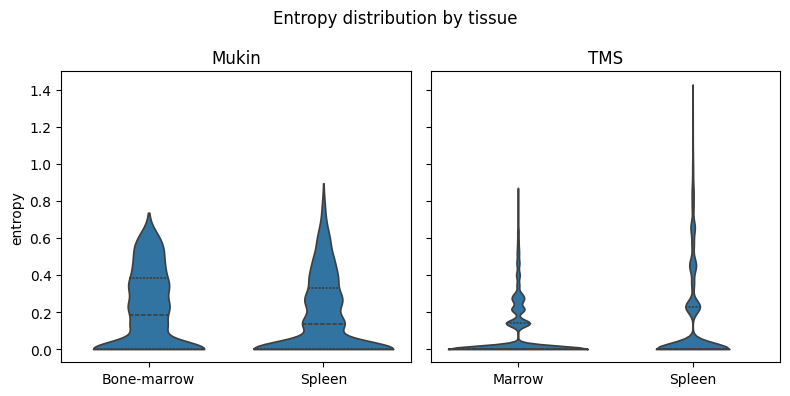

In [6]:
entropy_data = pd.concat(
    [
        mukin_adata.obs[["tissue", "entropy"]].assign(dataset="Mukin"),
        tms_adata.obs[["tissue", "entropy"]].assign(dataset="TMS"),
    ],
    ignore_index=True,
).dropna(subset=["entropy"])

fig, axes = plt.subplots(1, 2, figsize=(8, 4), sharey=True)
for ax, dataset in zip(axes, ["Mukin", "TMS"]):
    sns.violinplot(data=entropy_data[entropy_data["dataset"] == dataset], x="tissue", y="entropy", inner="quartile", cut=0, ax=ax)
    ax.set_title(dataset)
    ax.set_xlabel("")

fig.suptitle("Entropy distribution by tissue")
plt.tight_layout()

In [7]:
entropy_summary = (
    entropy_data.groupby(["dataset", "tissue"], observed=True)["entropy"]
    .agg(
        n_cells_with_entropy="size",
        n_cells_below_0_3=lambda values: (values < 0.3).sum(),
        percentage_below_0_3=lambda values: 100 * (values < 0.3).mean(),
    )
    .reset_index()
)
print(entropy_summary.to_string(index=False))

dataset      tissue  n_cells_with_entropy  n_cells_below_0_3  percentage_below_0_3
  Mukin Bone-marrow                  2377               1552             65.292385
  Mukin      Spleen                  2118               1584             74.787535
    TMS      Marrow                 45512              41878             92.015293
    TMS      Spleen                 25951              20674             79.665523


# system biology theory

In [8]:
mukin_bm_root = Path("/scratch/chenxi.sun/thesis_project/mukin_qcdata/AllRef_BM_0204")
tms_bm_root = Path("/scratch/chenxi.sun/thesis_project/tms_qcdata/AllRef_BM_0204")

mukin_astrid = load_and_concat_h5ad(discover_astrid_h5ad_files(mukin_bm_root), "mukin_bm")
flagged_clusters = find_rbc_contaminated_mukin_clusters(mukin_bm_root / "BM_combined_ASTRID_results.csv")
mukin_astrid = relabel_mukin_rbc_contamination(mukin_astrid, flagged_clusters)
mukin_astrid = filter_rare_celltypes(mukin_astrid, "SingleR_CellType", min_cells=100)

tms_astrid = prepare_tms_dataset(tms_bm_root)

mukin_obs = mukin_astrid.obs[["mouseID", "tissue", "model", "age", "SingleR_CellType"]].copy()
mukin_obs = mukin_obs.rename(columns={"mouseID": "mouse_id", "model": "microbiota", "SingleR_CellType": "cell_type"})
mukin_obs["dataset"] = "Mukin"
mukin_obs["sex"] = ""
mukin_condition_map = {
    ("SPF", "2m"): "Mukin SPF young",
    ("GF", "2m"): "Mukin GF young",
    ("SPF", "19m"): "Mukin SPF old",
    ("GF", "19m"): "Mukin GF old",
}
mukin_obs["condition"] = [mukin_condition_map[(model, age)] for model, age in zip(mukin_obs["microbiota"], mukin_obs["age"])]

tms_obs = tms_astrid.obs[["mouse.id", "tissue", "age", "sex", "age_group", "celltype_hb"]].copy()
tms_obs = tms_obs.rename(columns={"mouse.id": "mouse_id", "celltype_hb": "cell_type"})
tms_obs["dataset"] = "TMS"
tms_obs["microbiota"] = ""
tms_condition_map = {
    ("young", "male"): "TMS male young",
    ("young", "female"): "TMS female young",
    ("old", "male"): "TMS male old",
    ("old", "female"): "TMS female old",
}
tms_obs["condition"] = [tms_condition_map.get((age_group, sex)) for age_group, sex in zip(tms_obs["age_group"], tms_obs["sex"])]
tms_obs = tms_obs.dropna(subset=["condition"])

abundance_obs = pd.concat([mukin_obs, tms_obs], ignore_index=True)
abundance_obs["tissue"] = abundance_obs["tissue"].replace({"Bone-marrow": "Marrow"})

mouse_columns = ["dataset", "mouse_id", "tissue", "condition", "age", "sex", "microbiota"]
mouse_metadata = abundance_obs[mouse_columns].drop_duplicates()
assert not mouse_metadata.duplicated(["dataset", "mouse_id", "tissue"]).any()

mouse_totals = (
    abundance_obs.groupby(["dataset", "mouse_id", "tissue"], observed=True)
    .size().rename("n_total").reset_index()
)
celltype_counts = (
    abundance_obs.groupby(["dataset", "mouse_id", "tissue", "cell_type"], observed=True)
    .size().rename("n_celltype").reset_index()
)
all_celltypes = sorted(abundance_obs["cell_type"].astype(str).unique())
abundance_table = (
    mouse_metadata.merge(mouse_totals, on=["dataset", "mouse_id", "tissue"])
    .merge(pd.DataFrame({"cell_type": all_celltypes}), how="cross")
    .merge(celltype_counts, on=["dataset", "mouse_id", "tissue", "cell_type"], how="left")
)
abundance_table["n_celltype"] = abundance_table["n_celltype"].fillna(0).astype(int)
abundance_table["abundance"] = abundance_table["n_celltype"] / abundance_table["n_total"]
abundance_table["abundance_percent"] = 100 * abundance_table["abundance"]
selected_celltypes = [
    "B immature", "B pre", "basophil", "dendritic", "ILC", "monocyte", "monocyte pro",
    "myeloid progenitor", "myelomonocyte", "neutrophil", "neutrophil immature",
    "neutrophil maturing", "neutrophil progenitor", "T CD8",
]
abundance_table["in_all_8_conditions"] = abundance_table["cell_type"].isin(selected_celltypes)
abundance_table = abundance_table.sort_values(["dataset", "mouse_id", "cell_type"]).reset_index(drop=True)

abundance_output = Path("/scratch/chenxi.sun/RA project/system_biology/outputs/astrid_mouse_cell_abundance.csv")
abundance_output.parent.mkdir(exist_ok=True)
abundance_table.to_csv(abundance_output, index=False)
abundance_table

,dataset,mouse_id,tissue,condition,age,sex,microbiota,n_total,cell_type,n_celltype,abundance,abundance_percent,in_all_8_conditions
0,Mukin,GF_19m_2,Marrow,Mukin GF old,19m,,GF,1141,B age,59,0.051709,5.170903,False
1,Mukin,GF_19m_2,Marrow,Mukin GF old,19m,,GF,1141,B immature,111,0.097283,9.728309,True
2,Mukin,GF_19m_2,Marrow,Mukin GF old,19m,,GF,1141,B naive,0,0.000000,0.000000,False
3,Mukin,GF_19m_2,Marrow,Mukin GF old,19m,,GF,1141,B pre,53,0.046450,4.645048,True
4,Mukin,GF_19m_2,Marrow,Mukin GF old,19m,,GF,1141,ILC,16,0.014023,1.402279,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...
475,TMS,3-F-57,Marrow,TMS female young,3m,female,,3983,neutrophil,524,0.131559,13.155913,True
476,TMS,3-F-57,Marrow,TMS female young,3m,female,,3983,neutrophil immature,306,0.076827,7.682651,True
477,TMS,3-F-57,Marrow,TMS female young,3m,female,,3983,neutrophil maturing,573,0.143861,14.386141,True
478,TMS,3-F-57,Marrow,TMS female young,3m,female,,3983,neutrophil progenitor,103,0.025860,2.585990,True


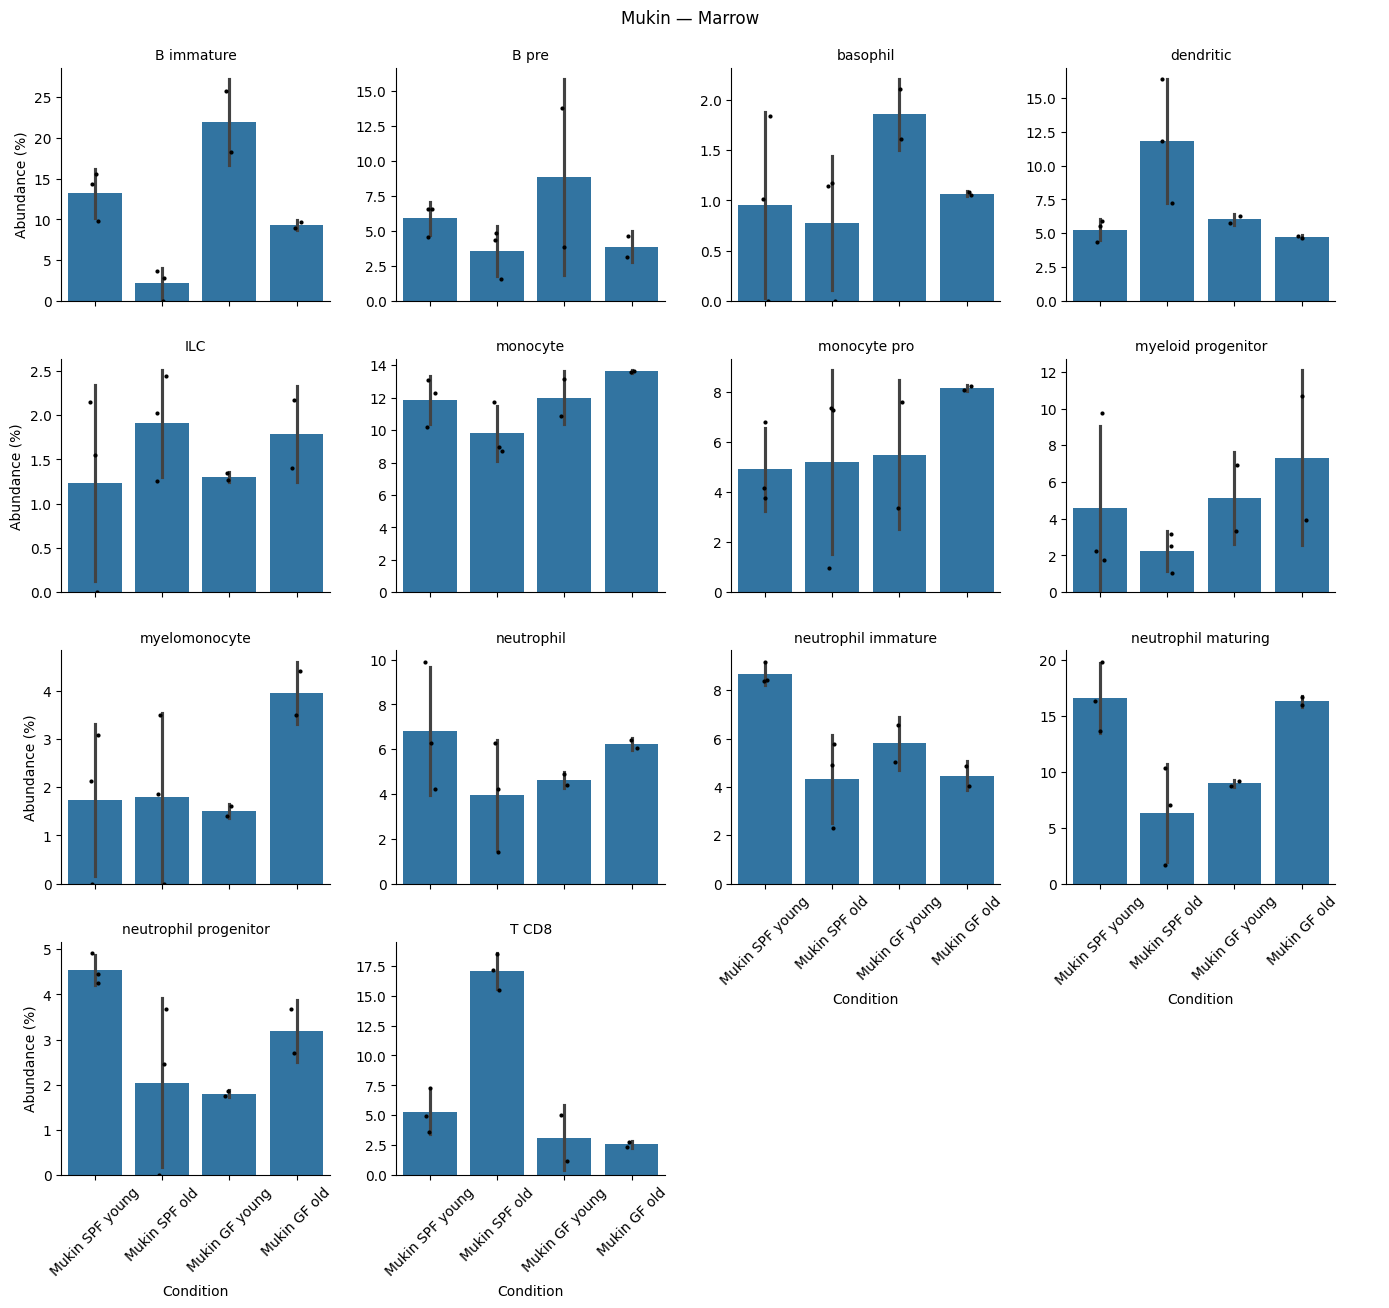

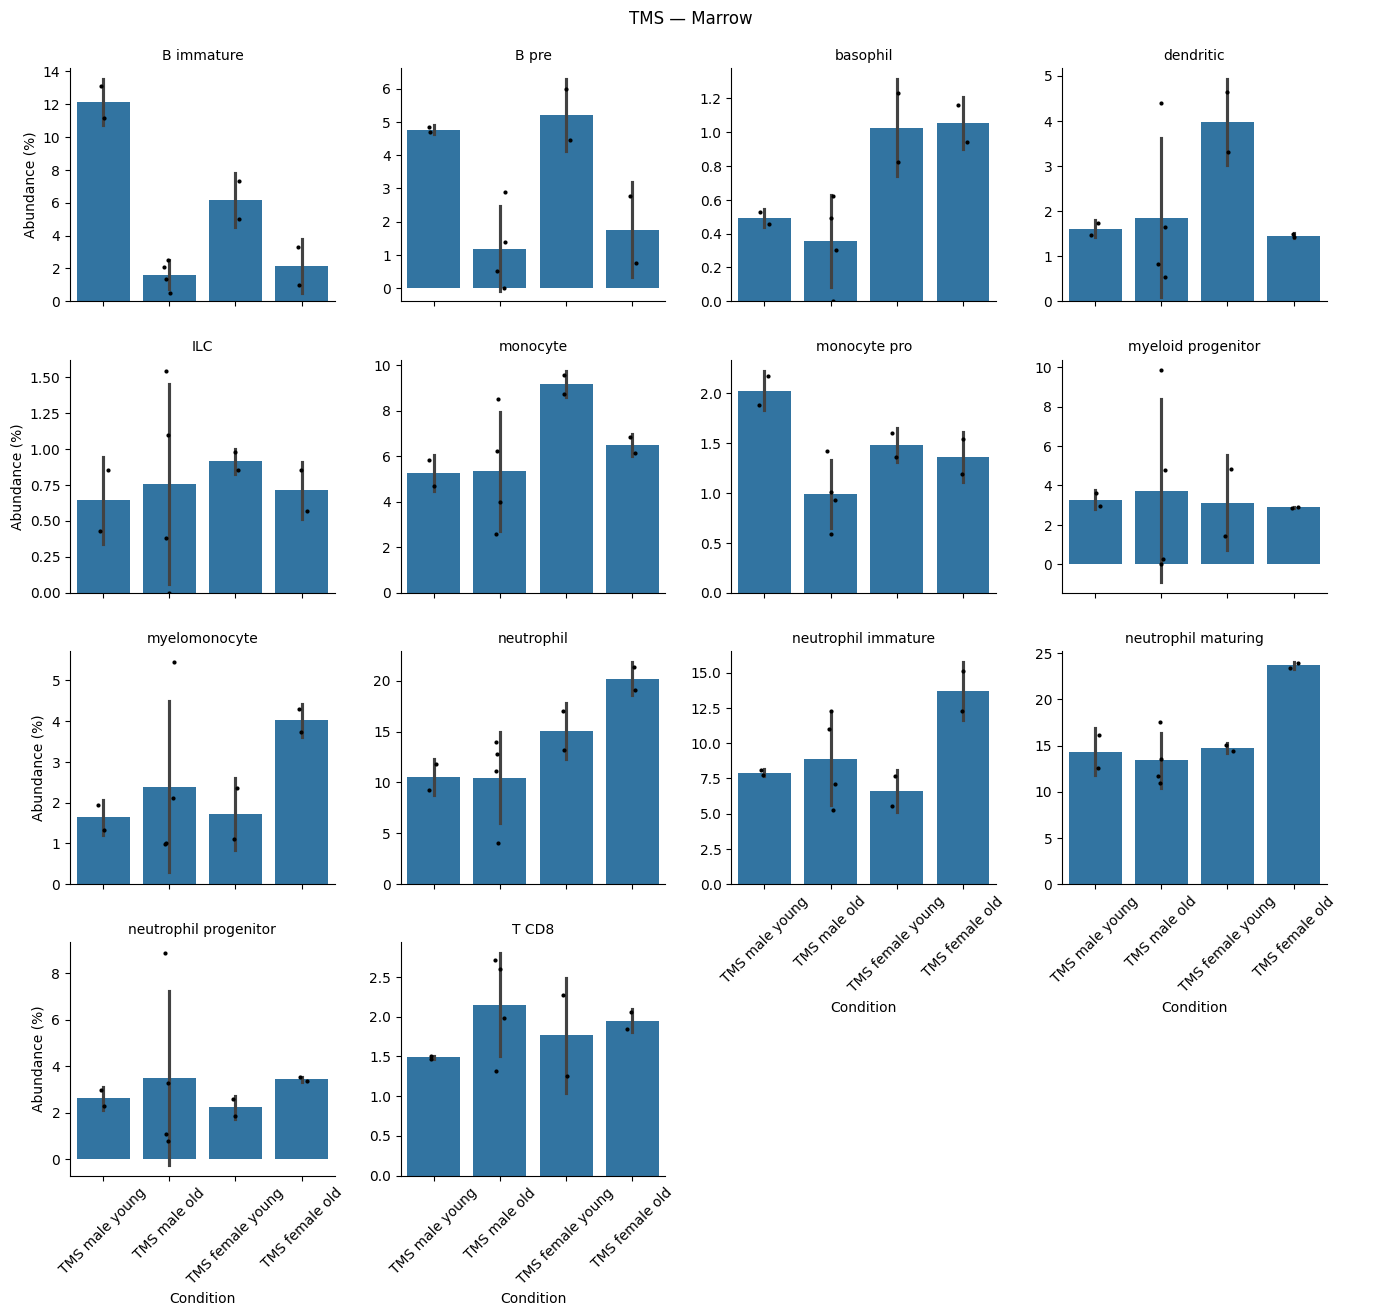

In [9]:
abundance_table = pd.read_csv("/scratch/chenxi.sun/RA project/system_biology/outputs/astrid_mouse_cell_abundance.csv")
selected_celltypes = [
    "B immature", "B pre", "basophil", "dendritic", "ILC", "monocyte", "monocyte pro",
    "myeloid progenitor", "myelomonocyte", "neutrophil", "neutrophil immature",
    "neutrophil maturing", "neutrophil progenitor", "T CD8",
]
condition_orders = {
    "Mukin": ["Mukin SPF young", "Mukin SPF old", "Mukin GF young", "Mukin GF old"],
    "TMS": ["TMS male young", "TMS male old", "TMS female young", "TMS female old"],
}
output_dir = Path("/scratch/chenxi.sun/RA project/system_biology/outputs")
output_dir.mkdir(exist_ok=True)
plot_data = abundance_table[abundance_table["in_all_8_conditions"]]
for dataset, condition_order in condition_orders.items():
    dataset_data = plot_data[plot_data["dataset"] == dataset]
    g = sns.catplot(
        data=dataset_data,
        x="condition",
        y="abundance_percent",
        col="cell_type",
        col_order=selected_celltypes,
        col_wrap=4,
        kind="bar",
        order=condition_order,
        errorbar="sd",
        height=3,
        aspect=1.15,
        sharey=False,
    )
    g.map_dataframe(
        sns.stripplot,
        x="condition",
        y="abundance_percent",
        order=condition_order,
        color="black",
        jitter=0.08,
        size=3,
    )
    g.set_axis_labels("Condition", "Abundance (%)")
    g.set_titles("{col_name}")
    g.figure.suptitle(f"{dataset} — Marrow", y=1.02)
    for ax in g.axes.flat:
        ax.tick_params(axis="x", rotation=45)
    g.figure.savefig(output_dir / f"abundance_variation_Marrow_{dataset}.png", dpi=300, bbox_inches="tight")
    plt.show()

## Cell-type coverage across the eight conditions

Use the five ASTRID-based rates tables and exclude the TMS age-mixed table. Cell-type names are matched only after trimming whitespace and converting to lower case; no biologically similar labels are merged. A value of 1 means that a rate is available for that condition.

In [10]:
condition_labels = {
    "young_spf": ("Mukin SPF young", "M-SPF-Y"),
    "young_gf": ("Mukin GF young", "M-GF-Y"),
    "old_spf": ("Mukin SPF old", "M-SPF-O"),
    "old_gf": ("Mukin GF old", "M-GF-O"),
    "young_male": ("TMS male young", "T-M-Y"),
    "young_female": ("TMS female young", "T-F-Y"),
    "old_male": ("TMS male old", "T-M-O"),
    "old_female": ("TMS female old", "T-F-O"),
}

rates_8conditions = pd.concat(
    [
        mukin_spf_age_tidyi[
            (mukin_spf_age_tidyi["tissue"] == "Bone-marrow")
            & mukin_spf_age_tidyi["comparison_group"].isin(["young_spf", "old_spf"])
        ].assign(dataset="Mukin", source_csv="mukin_young_spf_vs_old_spf"),
        mukin_young_microbiota_tidyi[
            (mukin_young_microbiota_tidyi["tissue"] == "Bone-marrow")
            & (mukin_young_microbiota_tidyi["comparison_group"] == "young_gf")
        ].assign(dataset="Mukin", source_csv="mukin_young_spf_vs_young_gf"),
        mukin_old_microbiota_tidyi[
            (mukin_old_microbiota_tidyi["tissue"] == "Bone-marrow")
            & (mukin_old_microbiota_tidyi["comparison_group"] == "old_gf")
        ].assign(dataset="Mukin", source_csv="mukin_old_spf_vs_old_gf"),
        tms_young_sex_tidyi[tms_young_sex_tidyi["tissue"] == "Marrow"].assign(
            dataset="TMS", source_csv="tms_young_male_vs_young_female"
        ),
        tms_old_sex_tidyi[tms_old_sex_tidyi["tissue"] == "Marrow"].assign(
            dataset="TMS", source_csv="tms_old_male_vs_old_female"
        ),
    ],
    ignore_index=True,
)
rates_8conditions["celltype_key"] = rates_8conditions["celltype"].astype("string").str.strip().str.lower()
rates_8conditions["condition"] = rates_8conditions["comparison_group"].map(lambda x: condition_labels[x][0])
rates_8conditions["condition_code"] = rates_8conditions["comparison_group"].map(lambda x: condition_labels[x][1])

assert not rates_8conditions.duplicated(["condition", "celltype_key"]).any()
condition_order = [label for label, code in condition_labels.values()]
celltype_coverage = pd.crosstab(rates_8conditions["celltype_key"], rates_8conditions["condition"])
celltype_coverage = celltype_coverage.reindex(columns=condition_order, fill_value=0).astype(int)
celltype_coverage["n_conditions"] = celltype_coverage.sum(axis=1)
celltype_coverage["all_8"] = celltype_coverage["n_conditions"].eq(8)
celltype_coverage.index.name = "celltype"
display(celltype_coverage)
print(f"Cell types present in all eight conditions: {celltype_coverage['all_8'].sum()}")

condition,Mukin SPF young,Mukin GF young,Mukin SPF old,Mukin GF old,TMS male young,TMS female young,TMS male old,TMS female old,n_conditions,all_8
celltype,,,,,,,,,,
b age,0,0,1,1,0,1,1,1,5,False
b immature,1,1,1,1,1,1,1,1,8,True
b naive,1,1,1,0,1,1,1,1,7,False
b pre,1,1,1,1,1,1,1,1,8,True
basophil,1,1,1,1,1,1,1,1,8,True
dendritic,1,1,1,1,1,1,1,1,8,True
erythroblast,0,0,0,0,1,1,1,1,4,False
erythrocyte,0,0,0,0,1,1,1,1,4,False
ilc,1,1,1,1,1,1,1,1,8,True


Cell types present in all eight conditions: 14


## Step 1: inspect whether abundance is a function of growth rate

Use the condition-pooled `percentage` and rates from the ASTRID-based TIDYI CSV files assembled above. The TMS age-mixed table is not used.

In [11]:
celltype_labels = {
    "b immature": "Immature B cell",
    "b pre": "Precursor B cell",
    "basophil": "Basophil",
    "dendritic": "Dendritic",
    "ilc": "ILC",
    "monocyte": "Monocyte",
    "monocyte pro": "Promonocyte",
    "myeloid progenitor": "Myeloid progenitor",
    "myelomonocyte": "Myelomonocyte",
    "neutrophil": "Neutrophil",
    "neutrophil immature": "Neutrophil immature",
    "neutrophil maturing": "Neutrophil maturing",
    "neutrophil progenitor": "Neutrophil progenitor",
    "t cd8": "T CD8",
}

all8_celltype_keys = celltype_coverage.index[celltype_coverage["all_8"]].tolist()
assert set(all8_celltype_keys) == set(celltype_labels)
step1_celltypes = [celltype_labels[key] for key in all8_celltype_keys]

step1_data = rates_8conditions[rates_8conditions["celltype_key"].isin(all8_celltype_keys)].copy()
step1_data["celltype"] = step1_data["celltype_key"].map(celltype_labels)
step1_data["gamma"] = step1_data["prolif_rate"] - step1_data["death_rate"]
step1_data["abundance_percent"] = step1_data["percentage"]
step1_data = step1_data.sort_values(["celltype", "dataset", "condition"]).reset_index(drop=True)

assert not step1_data.duplicated(["dataset", "condition", "celltype"]).any()
step1_data[["dataset", "condition", "celltype", "abundance_percent", "prolif_rate", "death_rate", "gamma", "source_csv"]]

,dataset,condition,celltype,abundance_percent,prolif_rate,death_rate,gamma,source_csv
0,Mukin,Mukin GF old,Basophil,1.069079,0.038514,0.010275,0.028239,mukin_old_spf_vs_old_gf
1,Mukin,Mukin GF young,Basophil,1.830407,0.053182,0.020863,0.032319,mukin_young_spf_vs_young_gf
2,Mukin,Mukin SPF old,Basophil,0.849634,0.082275,0.013466,0.068809,mukin_young_spf_vs_old_spf
3,Mukin,Mukin SPF young,Basophil,0.917679,0.003332,0.102399,-0.099067,mukin_young_spf_vs_old_spf
4,TMS,TMS female old,Basophil,1.058623,0.062991,0.005351,0.057639,tms_old_male_vs_old_female
...,...,...,...,...,...,...,...,...
107,Mukin,Mukin SPF young,T CD8,5.047233,0.012528,0.057261,-0.044733,mukin_young_spf_vs_old_spf
108,TMS,TMS female old,T CD8,1.946500,0.001891,0.016039,-0.014148,tms_old_male_vs_old_female
109,TMS,TMS female young,T CD8,1.766917,0.007734,0.032584,-0.024851,tms_young_male_vs_young_female
110,TMS,TMS male old,T CD8,2.089375,0.003443,0.038464,-0.035020,tms_old_male_vs_old_female


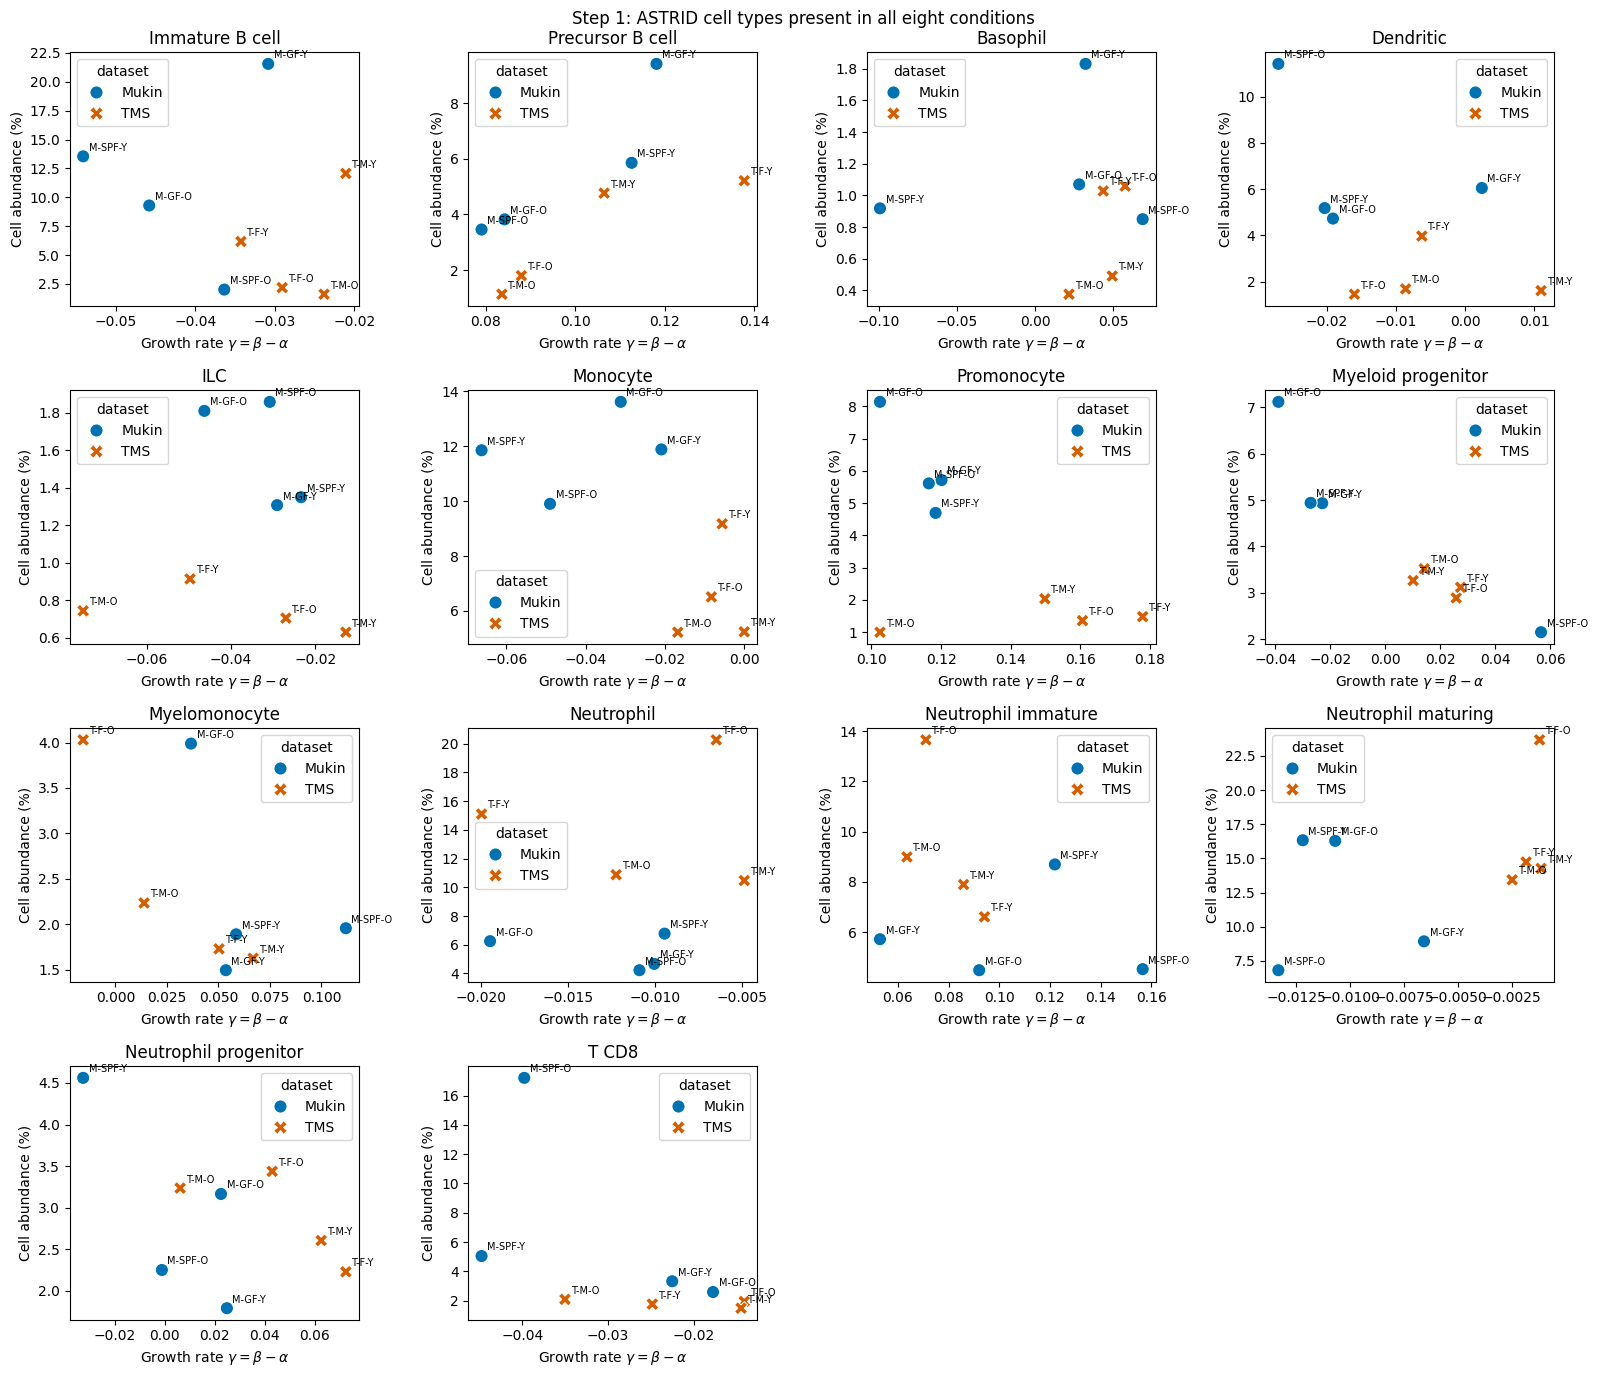

In [12]:
dataset_colors = {"Mukin": "#0072B2", "TMS": "#D55E00"}
n_cols = 4
n_rows = (len(step1_celltypes) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 3.5 * n_rows))

for ax, celltype in zip(axes.flat, step1_celltypes):
    plot_data = step1_data[step1_data["celltype"] == celltype]
    if plot_data.empty:
        ax.text(0.5, 0.5, "No marrow TIDYI rate available", ha="center", va="center", transform=ax.transAxes)
        ax.set_title(celltype)
        ax.set_axis_off()
        continue
    sns.scatterplot(
        data=plot_data,
        x="gamma",
        y="abundance_percent",
        hue="dataset",
        style="dataset",
        palette=dataset_colors,
        s=90,
        ax=ax,
    )
    for row in plot_data.itertuples():
        ax.annotate(row.condition_code, (row.gamma, row.abundance_percent), xytext=(4, 4), textcoords="offset points", fontsize=7)
    ax.set_title(celltype)
    ax.set_xlabel(r"Growth rate $\gamma=\beta-\alpha$")
    ax.set_ylabel("Cell abundance (%)")

for ax in axes.flat[len(step1_celltypes):]:
    ax.set_visible(False)

fig.suptitle(r"Step 1: Marrow ASTRID cell types present in all eight conditions")
plt.tight_layout()
fig.savefig(output_dir / "step1_scatter_Marrow_combined.png", dpi=300, bbox_inches="tight")
plt.show()

# grid search

M4: x = kb / (ka - gamma). For each of the six selected cell types, combine four Mukin and four TMS pooled conditions and fit one shared ka and kb to all eight points. Both kb and every observed ka - gamma must be strictly positive. Invalid grid points are masked. Minimize the unweighted SSE across the eight abundance fractions. Extend the grid by one decade toward boundary minima, up to six extensions; unresolved edge minima remain flagged. A logarithmic color scale displays large errors without changing the objective. A grid minimum alone does not demonstrate parameter identifiability or a good fit.

## M4

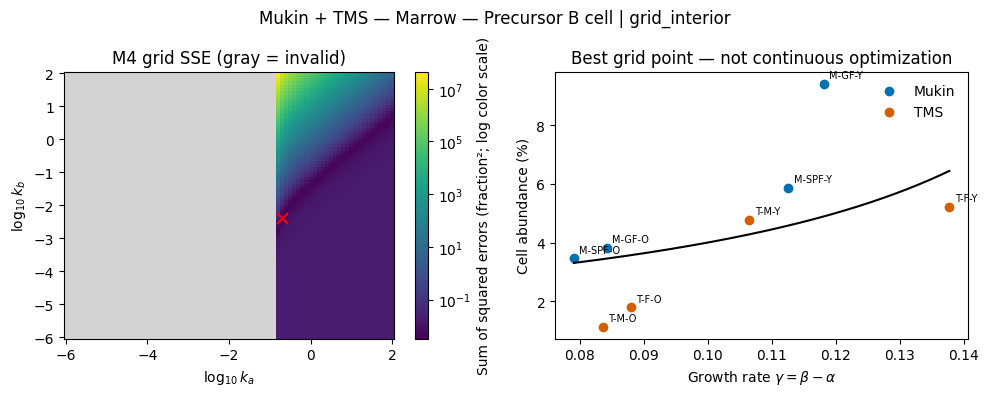

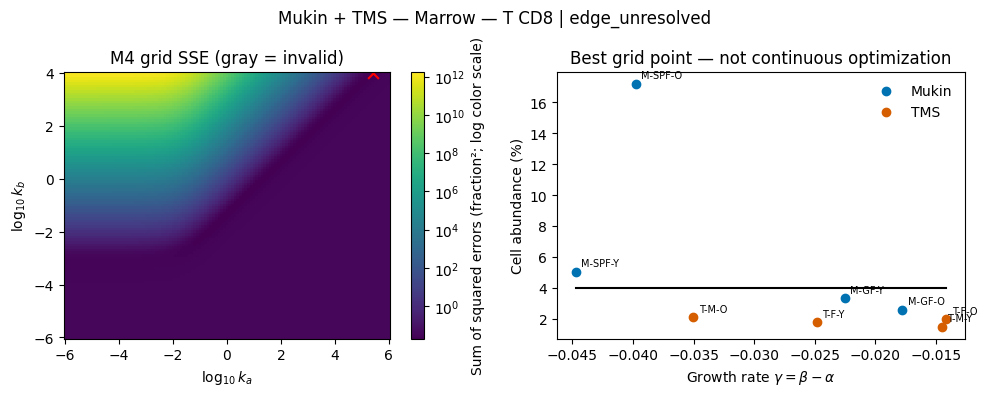

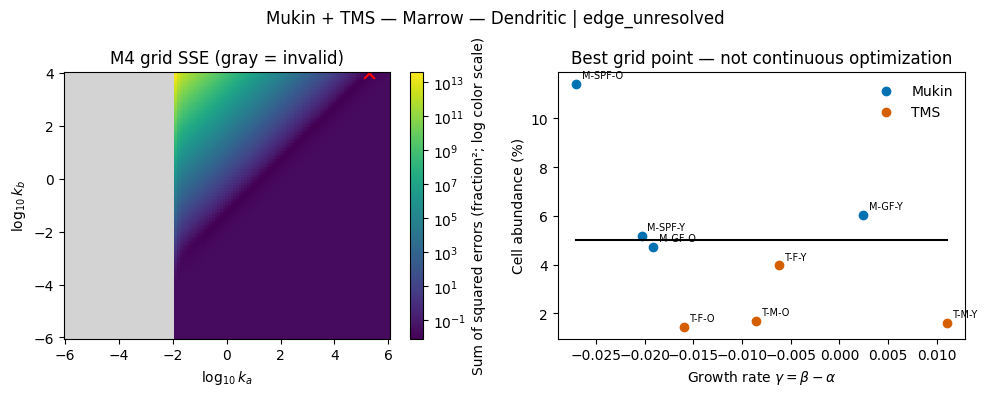

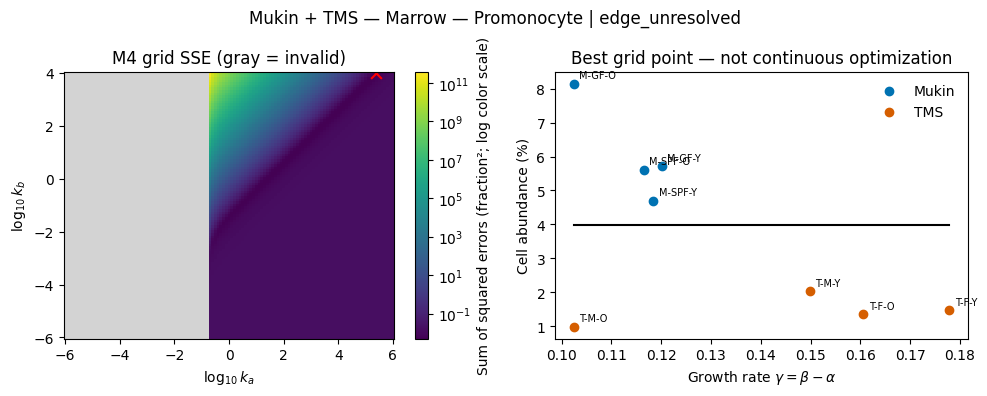

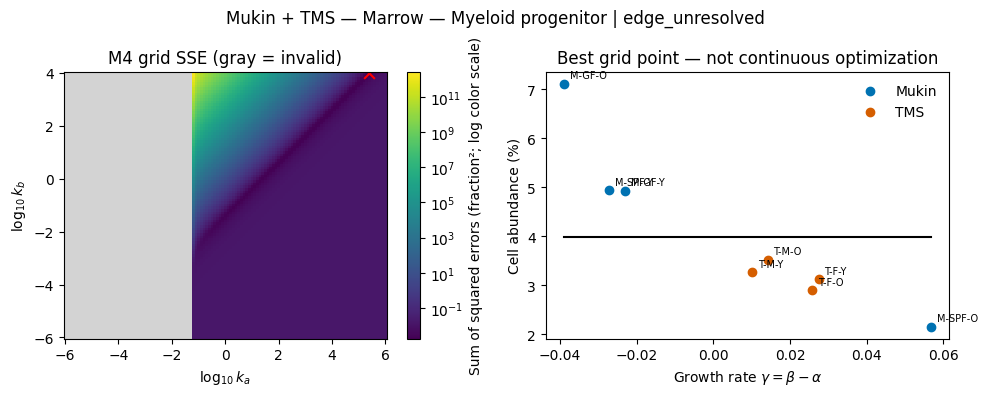

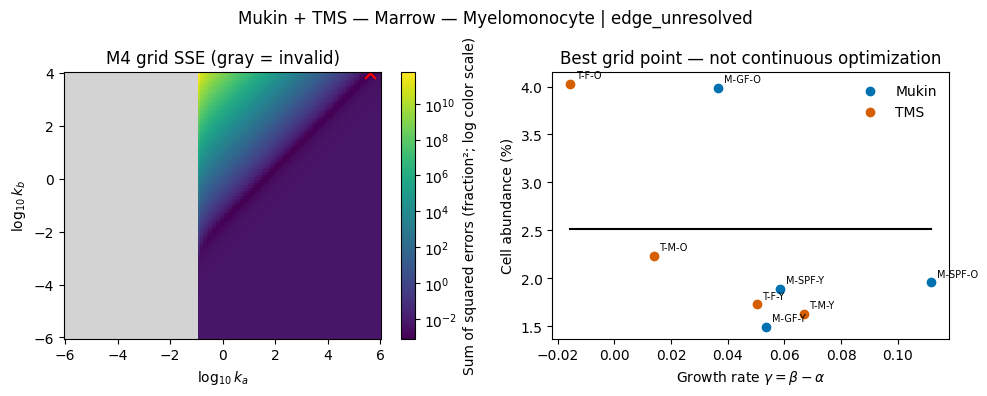

,dataset,tissue,celltype,n_conditions,ka,kb,SSE,RMSE_percent,min_denominator,log10_ka_min,log10_ka_max,log10_kb_min,log10_kb_max,log10_step,extensions,status,source_csv,abundance_source
0,Mukin+TMS,Marrow,Precursor B cell,8,0.199526,0.003981,0.003243,2.013283,0.061809,-6.0,2.0,-6.0,2.0,0.1,0,grid_interior,mukin_old_spf_vs_old_gf_tidyi.csv;mukin_young_...,condition-pooled percentage / 100
1,Mukin+TMS,Marrow,T CD8,8,251188.643151,10000.000000,0.019735,4.966810,251188.657299,-6.0,6.0,-6.0,4.0,0.1,6,edge_unresolved,mukin_old_spf_vs_old_gf_tidyi.csv;mukin_young_...,condition-pooled percentage / 100
2,Mukin+TMS,Marrow,Dendritic,8,199526.231497,10000.000000,0.007859,3.134326,199526.220485,-6.0,6.0,-6.0,4.0,0.1,6,edge_unresolved,mukin_old_spf_vs_old_gf_tidyi.csv;mukin_young_...,condition-pooled percentage / 100
3,Mukin+TMS,Marrow,Promonocyte,8,251188.643151,10000.000000,0.004936,2.483919,251188.465273,-6.0,6.0,-6.0,4.0,0.1,6,edge_unresolved,mukin_old_spf_vs_old_gf_tidyi.csv;mukin_young_...,condition-pooled percentage / 100
4,Mukin+TMS,Marrow,Myeloid progenitor,8,251188.643151,10000.000000,0.001762,1.484262,251188.586408,-6.0,6.0,-6.0,4.0,0.1,6,edge_unresolved,mukin_old_spf_vs_old_gf_tidyi.csv;mukin_young_...,condition-pooled percentage / 100
5,Mukin+TMS,Marrow,Myelomonocyte,8,398107.170553,10000.000000,0.000769,0.980438,398107.058685,-6.0,6.0,-6.0,4.0,0.1,6,edge_unresolved,mukin_old_spf_vs_old_gf_tidyi.csv;mukin_young_...,condition-pooled percentage / 100


In [5]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.colors import LogNorm

rates_dir = Path("/scratch/chenxi.sun/TIDYI_Astrid-anno/ty_df")
output_dir = Path("/scratch/chenxi.sun/RA project/system_biology/outputs")
output_dir.mkdir(exist_ok=True)
rate_inputs = [
    ("mukin_young_spf_vs_old_spf_tidyi.csv", "Mukin", "Bone-marrow", ["young_spf", "old_spf"]),
    ("mukin_young_spf_vs_young_gf_tidyi.csv", "Mukin", "Bone-marrow", ["young_gf"]),
    ("mukin_old_spf_vs_old_gf_tidyi.csv", "Mukin", "Bone-marrow", ["old_gf"]),
    ("tms_young_male_vs_young_female_tidyi.csv", "TMS", "Marrow", ["young_male", "young_female"]),
    ("tms_old_male_vs_old_female_tidyi.csv", "TMS", "Marrow", ["old_male", "old_female"]),
]
condition_codes = {
    "young_spf": "M-SPF-Y", "old_spf": "M-SPF-O",
    "young_gf": "M-GF-Y", "old_gf": "M-GF-O",
    "young_male": "T-M-Y", "young_female": "T-F-Y",
    "old_male": "T-M-O", "old_female": "T-F-O",
}

rate_tables = []
for filename, dataset, tissue, groups in rate_inputs:
    table = pd.read_csv(rates_dir / filename)
    table = table[(table["tissue"] == tissue) & table["comparison_group"].isin(groups)].copy()
    table["dataset"] = dataset
    table["source_csv"] = filename
    rate_tables.append(table)

m4_data = pd.concat(rate_tables, ignore_index=True)
m4_data["celltype"] = m4_data["celltype"].astype("string").str.strip().str.lower()
m4_data["condition_code"] = m4_data["comparison_group"].map(condition_codes)
m4_data["gamma"] = m4_data["prolif_rate"] - m4_data["death_rate"]
m4_data["abundance_percent"] = m4_data["percentage"]
assert not m4_data.duplicated(["dataset", "comparison_group", "celltype"]).any()
all8_celltypes = (m4_data.groupby("celltype")["comparison_group"].nunique().loc[lambda n: n == 8].index)
selected_celltypes = {
    "b pre": "Precursor B cell",
    "dendritic": "Dendritic",
    "monocyte pro": "Promonocyte",
    "myeloid progenitor": "Myeloid progenitor",
    "myelomonocyte": "Myelomonocyte",
    "t cd8": "T CD8",
}
assert set(selected_celltypes).issubset(set(all8_celltypes))
m4_data = m4_data[m4_data["celltype"].isin(selected_celltypes)].copy()
dataset_colors = {"Mukin": "#0072B2", "TMS": "#D55E00"}

# x is a relative abundance (0–1); gamma keeps the units of the rates CSV.
log10_start = (-6, 2)
log10_step = 0.1
max_extensions = 6


def m4_grid_search(gamma, x):
    bounds = [list(log10_start), list(log10_start)]
    for extension in range(max_extensions + 1):
        log_ka = np.arange(bounds[0][0], bounds[0][1] + log10_step / 2, log10_step)
        log_kb = np.arange(bounds[1][0], bounds[1][1] + log10_step / 2, log10_step)
        ka, kb = 10.0 ** log_ka, 10.0 ** log_kb
        valid_ka = ka > gamma.max()
        sse = np.full((len(kb), len(ka)), np.inf)
        # Evaluate only points satisfying kb > 0 and ka - gamma > 0.
        predictions = kb[:, None, None] / (ka[valid_ka][None, :, None] - gamma)
        sse[:, valid_ka] = np.sum((predictions - x) ** 2, axis=2)
        if not np.isfinite(sse).any():
            if extension == max_extensions:
                raise ValueError("No feasible ka: increase the upper log10 ka bound.")
            bounds[0][1] += 1
            continue
        iy, ix = np.unravel_index(np.argmin(sse), sse.shape)
        edges = [ix == 0, ix == len(ka) - 1, iy == 0, iy == len(kb) - 1]
        if not any(edges) or extension == max_extensions:
            break
        for parameter, lower, upper in [(0, edges[0], edges[1]), (1, edges[2], edges[3])]:
            if lower:
                bounds[parameter][0] -= 1
            if upper:
                bounds[parameter][1] += 1
    return log_ka, log_kb, sse, ix, iy, extension, any(edges)


m4_rows = []
for celltype, data in m4_data.groupby("celltype", sort=False):
    celltype_label = selected_celltypes[celltype]
    assert len(data) == 8 and data["dataset"].value_counts().eq(4).all()
    gamma = data["gamma"].to_numpy(dtype=float)
    x = data["abundance_percent"].to_numpy(dtype=float) / 100
    assert np.isfinite(gamma).all() and np.isfinite(x).all()
    assert ((x >= 0) & (x <= 1)).all()
    log_ka, log_kb, sse, ix, iy, extensions, on_edge = m4_grid_search(gamma, x)
    best_ka, best_kb = 10.0 ** log_ka[ix], 10.0 ** log_kb[iy]
    assert best_kb > 0 and (best_ka - gamma > 0).all()

    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    finite_errors = sse[np.isfinite(sse)]
    norm = LogNorm(vmin=max(finite_errors.min(), 1e-16), vmax=max(finite_errors.max(), 1e-15))
    axes[0].set_facecolor("lightgray")
    heatmap = axes[0].pcolormesh(
        log_ka, log_kb, np.ma.masked_invalid(sse),
        shading="auto", cmap="viridis", norm=norm,
    )
    axes[0].scatter(log_ka[ix], log_kb[iy], marker="x", color="red", s=60)
    axes[0].set_xlabel(r"$\log_{10} k_a$")
    axes[0].set_ylabel(r"$\log_{10} k_b$")
    axes[0].set_title("M4 grid SSE (gray = invalid)")
    fig.colorbar(heatmap, ax=axes[0], label="Sum of squared errors (fraction²; log color scale)")

    for dataset, dataset_data in data.groupby("dataset"):
        axes[1].scatter(
            dataset_data["gamma"], dataset_data["abundance_percent"],
            color=dataset_colors[dataset], label=dataset,
        )
    for row in data.itertuples():
        axes[1].annotate(row.condition_code, (row.gamma, row.abundance_percent),
                         xytext=(4, 4), textcoords="offset points", fontsize=7)
    gamma_curve = np.linspace(gamma.min(), gamma.max(), 300)
    axes[1].plot(gamma_curve, 100 * best_kb / (best_ka - gamma_curve), color="black")
    axes[1].set_xlabel(r"Growth rate $\gamma=\beta-\alpha$")
    axes[1].set_ylabel("Cell abundance (%)")
    axes[1].set_title("Best grid point — not continuous optimization")
    axes[1].legend(frameon=False)
    status = "edge_unresolved" if on_edge else "grid_interior"
    fig.suptitle(f"Mukin + TMS — Marrow — {celltype_label} | {status}")
    fig.tight_layout()
    plt.show()
    plt.close(fig)

    m4_rows.append({
        "dataset": "Mukin+TMS", "tissue": "Marrow", "celltype": celltype_label,
        "n_conditions": len(data), "ka": best_ka, "kb": best_kb,
        "SSE": sse[iy, ix], "RMSE_percent": 100 * np.sqrt(sse[iy, ix] / len(data)),
        "min_denominator": (best_ka - gamma).min(),
        "log10_ka_min": log_ka[0], "log10_ka_max": log_ka[-1],
        "log10_kb_min": log_kb[0], "log10_kb_max": log_kb[-1],
        "log10_step": log10_step, "extensions": extensions, "status": status,
        "source_csv": ";".join(sorted(data["source_csv"].unique())),
        "abundance_source": "condition-pooled percentage / 100",
    })

m4_results = pd.DataFrame(m4_rows)
m4_results.to_csv(output_dir / "M4_grid_Marrow_combined_results.csv", index=False)
display(m4_results)


## M2/3

Searching Precursor B cell: eight combined conditions


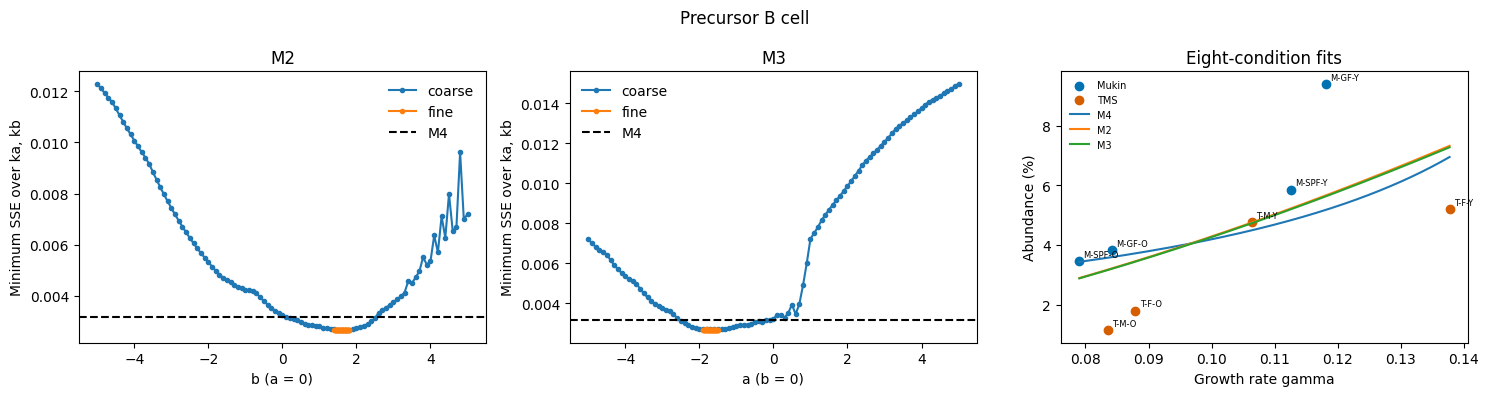

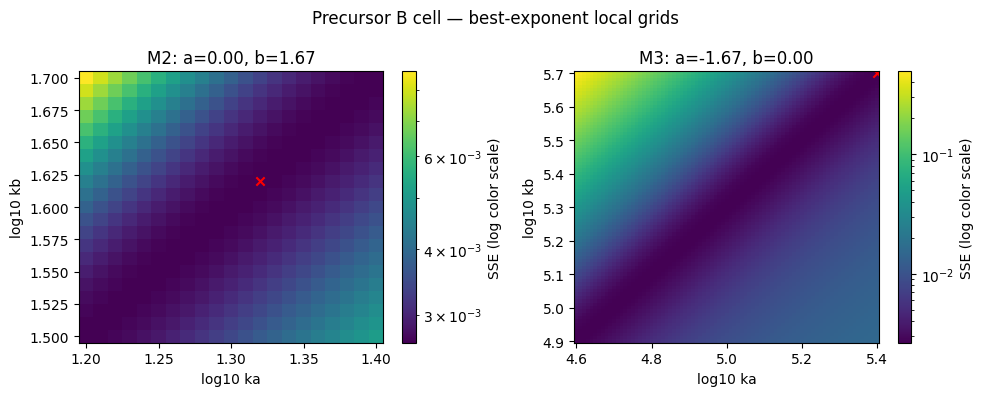

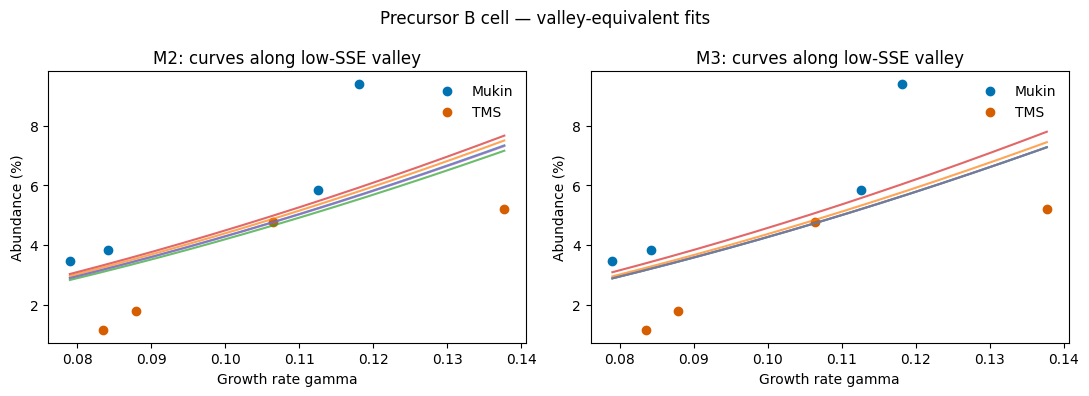

Searching Promonocyte: eight combined conditions


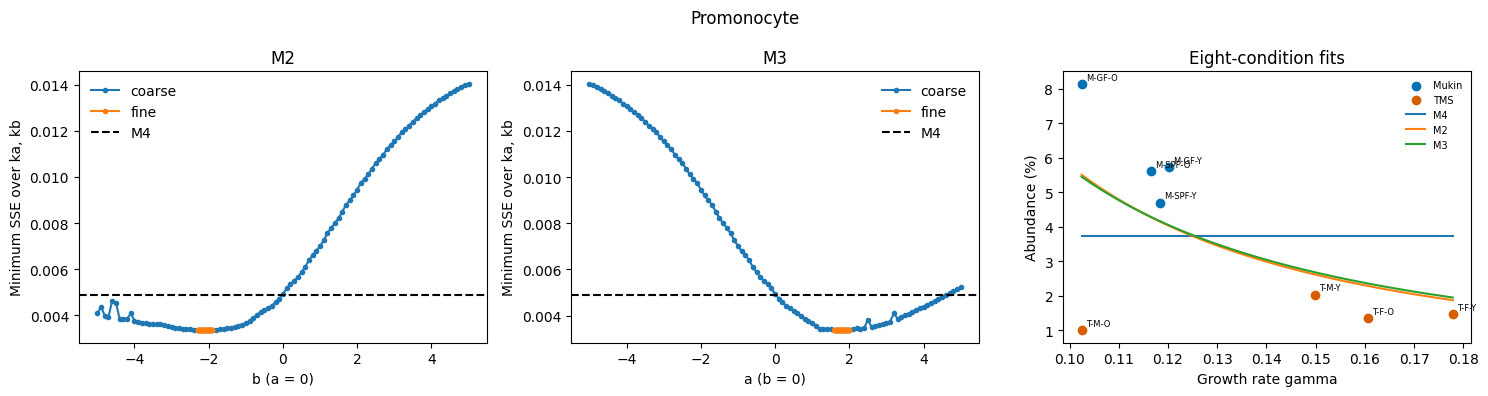

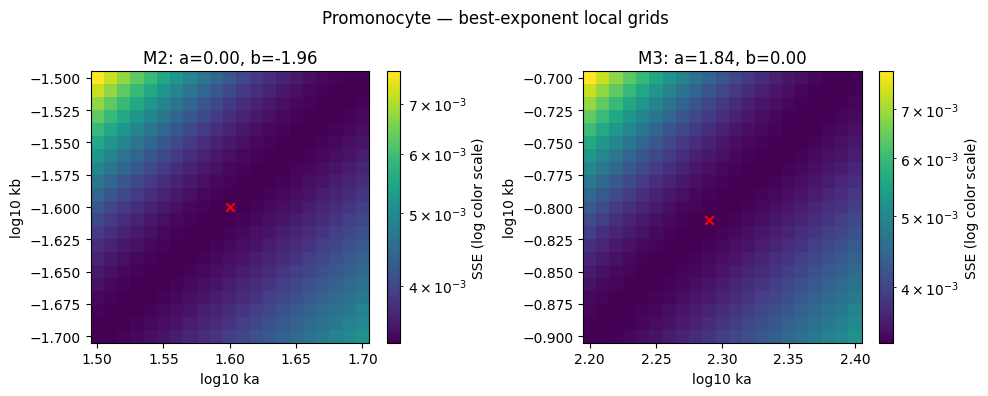

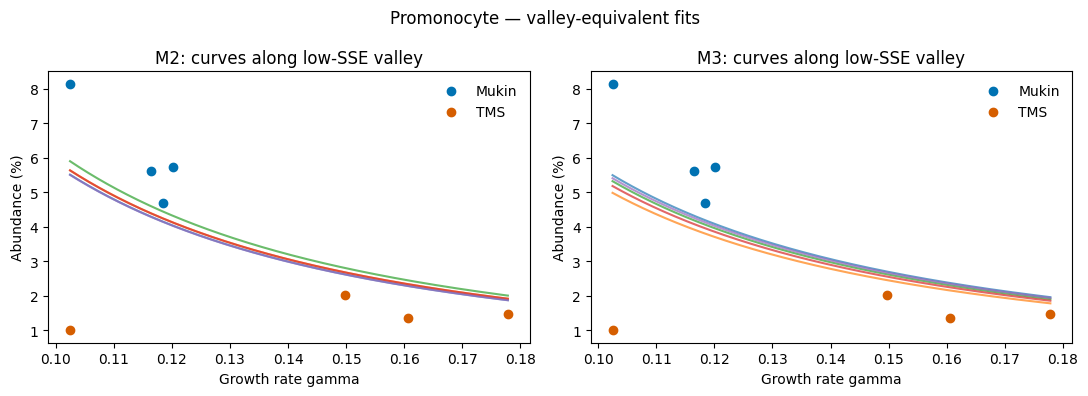

          celltype model  n_conditions     a     b            ka            kb      SSE  RMSE_percent  SSE_reduction_percent  min_denominator                           status                                                                                                                                                                                 source_csv  n_nonpositive_gamma
  Precursor B cell    M4             8  0.00  0.00      0.194984      0.003981 0.003178      1.992988               0.000000     5.726717e-02                    grid_interior mukin_old_spf_vs_old_gf_tidyi.csv;mukin_young_spf_vs_old_spf_tidyi.csv;mukin_young_spf_vs_young_gf_tidyi.csv;tms_old_male_vs_old_female_tidyi.csv;tms_young_male_vs_young_female_tidyi.csv                  NaN
  Precursor B cell    M2             8  0.00  1.67     20.892961     41.686938 0.002653      1.820895              16.524250     2.075524e+01                    grid_interior mukin_old_spf_vs_old_gf_tidyi.csv;mukin_young_spf_vs_old_sp

In [3]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.colors import LogNorm

rates_dir = Path("/scratch/chenxi.sun/TIDYI_Astrid-anno/ty_df")
output_dir = Path("/scratch/chenxi.sun/RA project/system_biology/outputs")
output_dir.mkdir(exist_ok=True)
rate_inputs = [
    ("mukin_young_spf_vs_old_spf_tidyi.csv", "Mukin", "Bone-marrow", ["young_spf", "old_spf"]),
    ("mukin_young_spf_vs_young_gf_tidyi.csv", "Mukin", "Bone-marrow", ["young_gf"]),
    ("mukin_old_spf_vs_old_gf_tidyi.csv", "Mukin", "Bone-marrow", ["old_gf"]),
    ("tms_young_male_vs_young_female_tidyi.csv", "TMS", "Marrow", ["young_male", "young_female"]),
    ("tms_old_male_vs_old_female_tidyi.csv", "TMS", "Marrow", ["old_male", "old_female"]),
]
condition_codes = {
    "young_spf": "M-SPF-Y", "old_spf": "M-SPF-O",
    "young_gf": "M-GF-Y", "old_gf": "M-GF-O",
    "young_male": "T-M-Y", "young_female": "T-F-Y",
    "old_male": "T-M-O", "old_female": "T-F-O",
}

rate_tables = []
for filename, dataset, tissue, groups in rate_inputs:
    table = pd.read_csv(rates_dir / filename)
    table = table[(table["tissue"] == tissue) & table["comparison_group"].isin(groups)].copy()
    table["dataset"] = dataset
    table["source_csv"] = filename
    rate_tables.append(table)

m23_data = pd.concat(rate_tables, ignore_index=True)
m23_data["celltype"] = m23_data["celltype"].astype("string").str.strip().str.lower()
m23_data["condition_code"] = m23_data["comparison_group"].map(condition_codes)
m23_data["gamma"] = m23_data["prolif_rate"] - m23_data["death_rate"]
m23_data["abundance_percent"] = m23_data["percentage"]
assert not m23_data.duplicated(["dataset", "comparison_group", "celltype"]).any()
all8_celltypes = (m23_data.groupby("celltype")["comparison_group"].nunique().loc[lambda n: n == 8].index)
selected_celltypes = {
    "b pre": "Precursor B cell",
    "dendritic": "Dendritic",
    "monocyte pro": "Promonocyte",
    "myeloid progenitor": "Myeloid progenitor",
    "myelomonocyte": "Myelomonocyte",
    "t cd8": "T CD8",
}
assert set(selected_celltypes).issubset(set(all8_celltypes))
m23_data = m23_data[m23_data["celltype"].isin(selected_celltypes)].copy()
dataset_colors = {"Mukin": "#0072B2", "TMS": "#D55E00"}

# Original power-law model: only gamma > 0 permits continuous exponents.
exponent_start = (-5, 5)
exponent_step = 0.1
fine_exponent_step = 0.01
max_extensions = 6


def m23_parameter_grid(gamma, x, a, b, bounds=None, step=0.1, extension_width=1):
    bounds = [list(v) for v in (bounds if bounds is not None else [(-6, 2), (-6, 2)])]
    for extension in range(max_extensions + 1):
        la, lb = [np.arange(lo, hi + step / 2, step) for lo, hi in bounds]
        ka, kb = 10.0 ** la, 10.0 ** lb
        denominator = ka[:, None] * gamma ** a - gamma
        valid = (denominator > 0).all(axis=1)
        sse = np.full((len(kb), len(ka)), np.inf)
        predictions = kb[:, None, None] * gamma ** b / denominator[valid][None, :, :]
        sse[:, valid] = np.sum((predictions - x) ** 2, axis=2)
        if not np.isfinite(sse).any():
            if extension == max_extensions:
                raise ValueError("No feasible grid point: increase the ka upper bound.")
            bounds[0][1] += extension_width
            continue
        iy, ix = np.unravel_index(np.argmin(sse), sse.shape)
        edges = [ix == 0, ix == len(la)-1, iy == 0, iy == len(lb)-1]
        if not any(edges) or extension == max_extensions:
            break
        for k, lower, upper in [(0, edges[0], edges[1]), (1, edges[2], edges[3])]:
            bounds[k][0] -= extension_width * lower
            bounds[k][1] += extension_width * upper
    return {"a": a, "b": b, "la": la, "lb": lb, "sse": sse,
            "ix": ix, "iy": iy, "ka": ka[ix], "kb": kb[iy],
            "SSE": sse[iy, ix], "parameter_edge": any(edges)}


def m23_fit_at_exponent(gamma, x, model, exponent, refine=False):
    a, b = (0, exponent) if model == "M2" else (exponent, 0)
    fit = m23_parameter_grid(gamma, x, a, b)
    if refine:
        center = [fit["la"][fit["ix"]], fit["lb"][fit["iy"]]]
        fine = m23_parameter_grid(gamma, x, a, b,
                                 bounds=[(v-0.1, v+0.1) for v in center],
                                 step=0.01, extension_width=0.1)
        fine["parameter_edge"] |= fit["parameter_edge"]
        if fine["SSE"] <= fit["SSE"]:
            fit = fine
    return fit


def m23_profile(gamma, x, model):
    lo, hi = exponent_start
    cache = {}
    for extension in range(max_extensions + 1):
        values = np.round(np.arange(lo, hi + exponent_step/2, exponent_step), 8)
        for e in values:
            if e not in cache:
                cache[e] = m23_fit_at_exponent(gamma, x, model, e)
        best_e = min(values, key=lambda e: cache[e]["SSE"])
        exponent_edge = best_e == values[0] or best_e == values[-1]
        if not exponent_edge or extension == max_extensions:
            break
        lo -= int(best_e == values[0])
        hi += int(best_e == values[-1])
    fine_values = np.unique(np.append(
        np.round(np.arange(best_e-0.2, best_e+0.2+fine_exponent_step/2, fine_exponent_step), 8), 0))
    fits = {e: m23_fit_at_exponent(gamma, x, model, e, refine=True) for e in fine_values}
    best = min(fits.values(), key=lambda f: f["SSE"])
    best["exponent_edge"] = exponent_edge or (
        np.isclose(best["a"] + best["b"], best_e-0.2) or
        np.isclose(best["a"] + best["b"], best_e+0.2))
    profile = [(e, f["SSE"], "coarse") for e, f in cache.items()]
    profile += [(e, f["SSE"], "fine") for e, f in fits.items() if abs(e-best_e) <= 0.2+1e-8]
    return best, pd.DataFrame(profile, columns=["exponent", "SSE", "stage"])

def select_valley_points(fit, tolerance=0.05, n_points=5):
    min_sse = fit["SSE"]
    threshold = min_sse * (1 + tolerance)

    iy, ix = np.where(np.isfinite(fit["sse"]) & (fit["sse"] <= threshold))

    if len(ix) == 0:
        return pd.DataFrame()

    valley = pd.DataFrame({
        "log10_ka": fit["la"][ix],
        "log10_kb": fit["lb"][iy],
        "SSE": fit["sse"][iy, ix],
    })

    valley = valley.sort_values("log10_ka")

    if len(valley) <= n_points:
        selected = valley
    else:
        positions = np.linspace(0, len(valley) - 1, n_points).astype(int)
        selected = valley.iloc[positions]

    selected = selected.copy()
    selected["ka"] = 10 ** selected["log10_ka"]
    selected["kb"] = 10 ** selected["log10_kb"]

    return selected

m23_rows = []
m23_fits = {}
for celltype, label in selected_celltypes.items():
    data = m23_data[m23_data["celltype"] == celltype]
    gamma = data["gamma"].to_numpy(dtype=float)
    x = data["abundance_percent"].to_numpy(dtype=float) / 100
    assert len(data) == 8 and data["dataset"].value_counts().eq(4).all()
    assert np.isfinite(gamma).all() and np.isfinite(x).all()
    assert ((x >= 0) & (x <= 1)).all()
    if (gamma <= 0).any():
        for model in ["M2", "M3"]:
            m23_rows.append({"celltype": label, "model": model, "n_conditions": 8,
                             "n_nonpositive_gamma": int((gamma <= 0).sum()),
                             "status": "not_applicable_nonpositive_gamma"})
        continue
    print(f"Searching {label}: eight combined conditions", flush=True)
    baseline = m23_fit_at_exponent(gamma, x, "M2", 0, refine=True)
    fitted = {"M4": baseline}
    profiles = {}
    for model in ["M2", "M3"]:
        fitted[model], profiles[model] = m23_profile(gamma, x, model)
    m23_fits[label] = fitted

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    for ax, model in zip(axes, ["M2", "M3"]):
        profile = profiles[model]
        for stage, points in profile.groupby("stage"):
            points = points.sort_values("exponent")
            ax.plot(points["exponent"], points["SSE"], ".-", label=stage)
        ax.axhline(baseline["SSE"], color="black", linestyle="--", label="M4")
        ax.set(xlabel="b (a = 0)" if model == "M2" else "a (b = 0)",
               ylabel="Minimum SSE over ka, kb", title=model)
        ax.legend(frameon=False)
    for dataset, points in data.groupby("dataset"):
        axes[2].scatter(points["gamma"], points["abundance_percent"],
                        color=dataset_colors[dataset], label=dataset)
    for row in data.itertuples():
        axes[2].annotate(row.condition_code, (row.gamma, row.abundance_percent),
                         xytext=(3, 3), textcoords="offset points", fontsize=6)
    curve_gamma = np.linspace(gamma.min(), gamma.max(), 400)
    for model, fit in fitted.items():
        denominator = fit["ka"] * curve_gamma ** fit["a"] - curve_gamma
        prediction = np.full_like(curve_gamma, np.nan)
        valid = denominator > 0
        prediction[valid] = 100 * fit["kb"] * curve_gamma[valid] ** fit["b"] / denominator[valid]
        axes[2].plot(curve_gamma, prediction, label=model)
        observed_denom = fit["ka"] * gamma ** fit["a"] - gamma
        assert (observed_denom > 0).all() and (fit["kb"] * gamma ** fit["b"] > 0).all()
        m23_rows.append({
            "celltype": label, "model": model, "n_conditions": 8,
            "a": fit["a"], "b": fit["b"], "ka": fit["ka"], "kb": fit["kb"],
            "SSE": fit["SSE"], "RMSE_percent": 100*np.sqrt(fit["SSE"]/8),
            "SSE_reduction_percent": 100*(1-fit["SSE"]/baseline["SSE"]),
            "min_denominator": observed_denom.min(),
            "status": "edge_unresolved" if fit["parameter_edge"] or fit.get("exponent_edge", False) else "grid_interior",
            "source_csv": ";".join(sorted(data["source_csv"].unique())),
        })
    axes[2].set(xlabel="Growth rate gamma", ylabel="Abundance (%)", title="Eight-condition fits")
    axes[2].legend(frameon=False, fontsize=7)
    fig.suptitle(label)
    fig.tight_layout()
    plt.show()
    plt.close(fig)

    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    for ax, model in zip(axes, ["M2", "M3"]):
        fit = fitted[model]
        finite = fit["sse"][np.isfinite(fit["sse"])]
        heatmap = ax.pcolormesh(fit["la"], fit["lb"], np.ma.masked_invalid(fit["sse"]),
                                shading="auto", cmap="viridis",
                                norm=LogNorm(vmin=max(finite.min(), 1e-16), vmax=max(finite.max(), 1e-15)))
        ax.set_facecolor("lightgray")
        ax.scatter(np.log10(fit["ka"]), np.log10(fit["kb"]), color="red", marker="x")
        ax.set(xlabel="log10 ka", ylabel="log10 kb",
               title=f'{model}: a={fit["a"]:.2f}, b={fit["b"]:.2f}')
        fig.colorbar(heatmap, ax=ax, label="SSE (log color scale)")
    fig.suptitle(label + " — best-exponent local grids")
    fig.tight_layout()
    plt.show()
    plt.close(fig)

    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    curve_gamma = np.linspace(gamma.min(), gamma.max(), 400)
    for ax, model in zip(axes, ["M2", "M3"]):
        fit = fitted[model]
        valley_points = select_valley_points(
            fit,
            tolerance=0.05,
            n_points=5,
        )

        for row in valley_points.itertuples():
            denominator = (
                row.ka * curve_gamma ** fit["a"]
                - curve_gamma
            )

            valid = denominator > 0

            prediction = np.full_like(
                curve_gamma,
                np.nan,
                dtype=float,
            )

            prediction[valid] = (
                100
                * row.kb
                * curve_gamma[valid] ** fit["b"]
                / denominator[valid]
            )

            ax.plot(
                curve_gamma,
                prediction,
                alpha=0.7,
            )

        for dataset, points in data.groupby("dataset"):
            ax.scatter(
                points["gamma"],
                points["abundance_percent"],
                color=dataset_colors[dataset],
                label=dataset,
            )

        ax.set(
            xlabel="Growth rate gamma",
            ylabel="Abundance (%)",
            title=f"{model}: curves along low-SSE valley",
        )

        ax.legend(frameon=False)

    fig.suptitle(label + " — valley-equivalent fits")
    fig.tight_layout()
    plt.show()
    plt.close(fig)
    

m23_results = pd.DataFrame(m23_rows)
m23_results.to_csv(output_dir / "M23_grid_Marrow_combined_results.csv", index=False)
print(m23_results.to_string(index=False))


# M2/3 refined

### Exponential-response refinement

The original dynamical framework is unchanged:

$$
\frac{dx}{dt}=B+(\gamma-A)x,\qquad \gamma=\beta-\alpha,
$$

so at equilibrium

$$
x=\frac{B}{A-\gamma}.
$$

The original power-law response is replaced by a dimensionless exponential response:

$$
z=\frac{\gamma-\gamma_{\mathrm{ref}}}{s_\gamma}=\frac{\gamma}{s_\gamma},\qquad
A=k_a e^{az},\qquad B=k_b e^{bz},
$$

with one global $s_\gamma$, calculated as the sample SD of all 48 cell-type-level $\gamma$ values included in this analysis. We keep $\gamma_{\mathrm{ref}}=0$, because $\gamma=0$ represents proliferation-death balance. Therefore,

$$
\boxed{x=\frac{k_b e^{bz}}{k_a e^{az}-\gamma}}.
$$

This formulation is used because it (i) accepts positive, zero, and negative $\gamma$; (ii) guarantees $A>0$ and $B>0$ for $k_a,k_b>0$; (iii) leaves $a$ and $b$ continuous and unconstrained in sign; and (iv) preserves the four nested biological models:

| Model | Constraint | Interpretation |
|---|---|---|
| M1 | $a,b$ free | growth-dependent regulation of both $A$ and $B$ |
| M2 | $a=0$, $b$ free | only $B$ is growth-dependent |
| M3 | $a$ free, $b=0$ | only $A$ is growth-dependent |
| M4 | $a=b=0$ | neither rate is growth-dependent |

For each of the six cell types, the code combines four Mukin and four TMS pooled conditions, fits a separate parameter set, repeats coarse-to-fine exponent profiling and $(k_a,k_b)$ valley diagnostics, and compares all four models using SSE, RMSE, AIC, AICc, and BIC. The only parameter shared across cell types is the global $s_\gamma$. All observed equilibrium denominators must remain strictly positive.

Global s_gamma = 0.063577741 from 48 gamma values
Gamma sign counts: 30 positive, 0 zero, 18 negative
Searching Precursor B cell: eight combined conditions


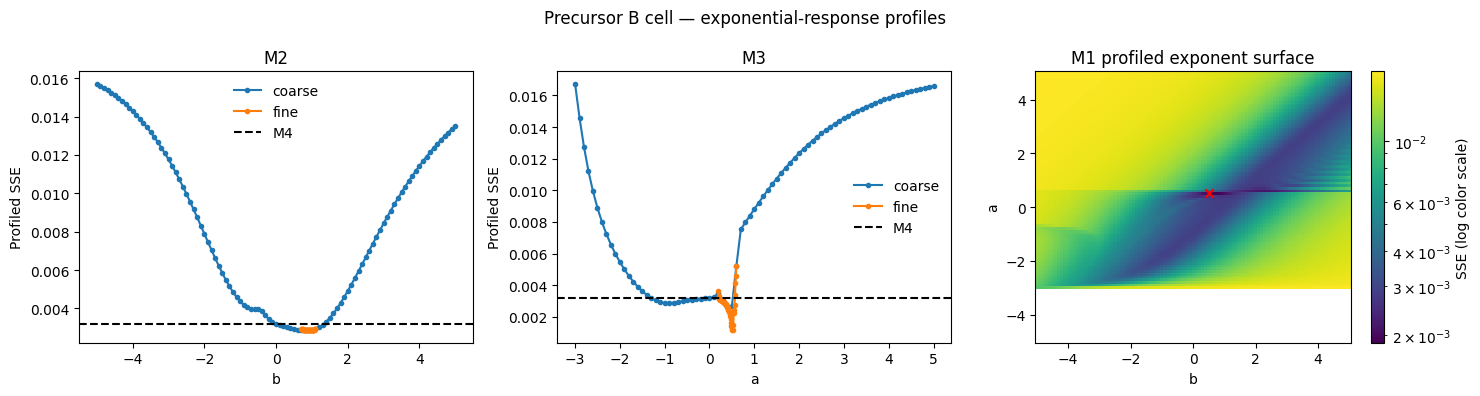

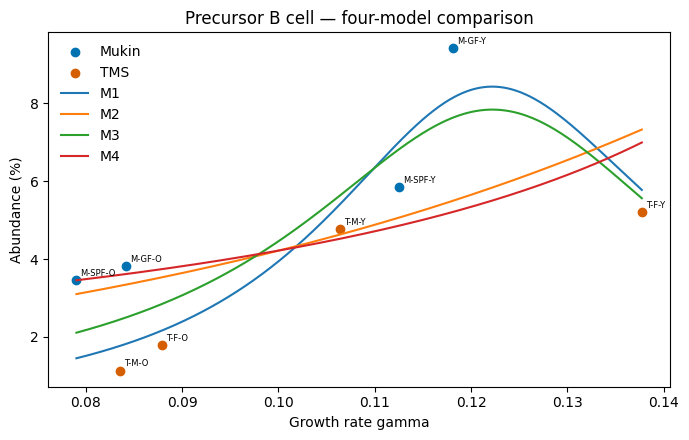

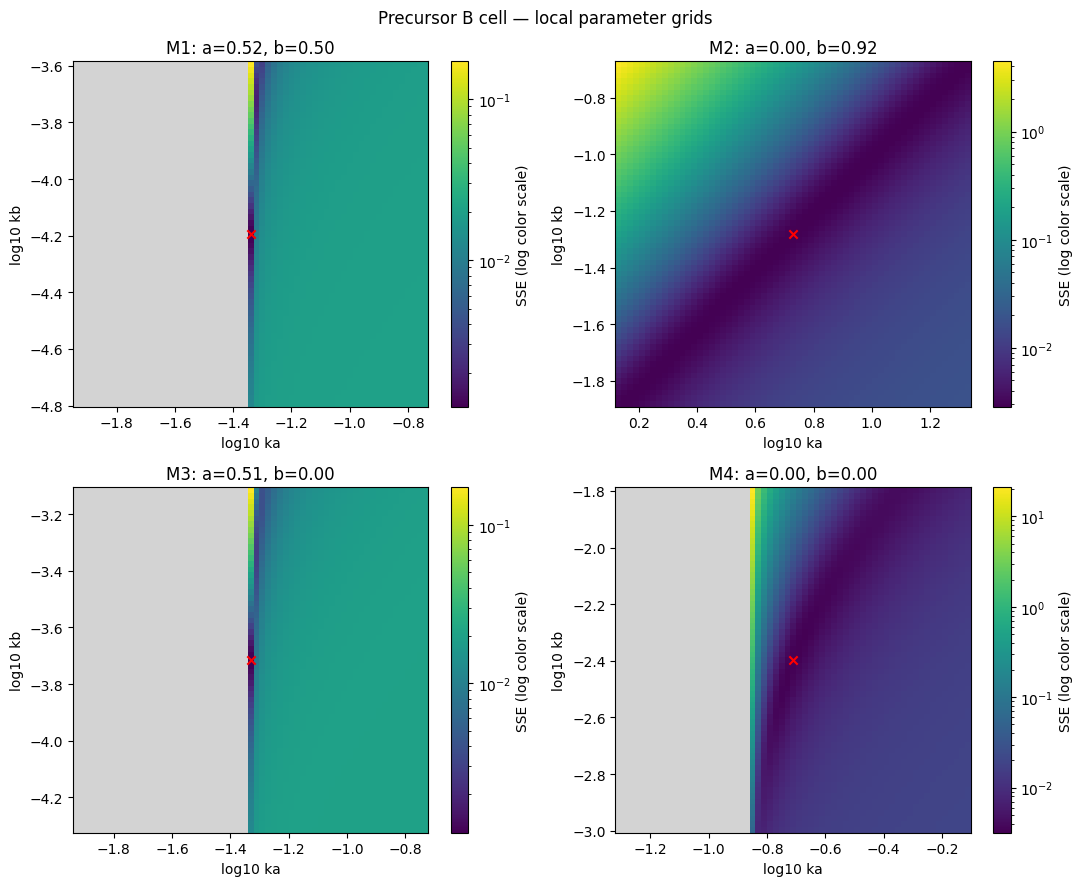

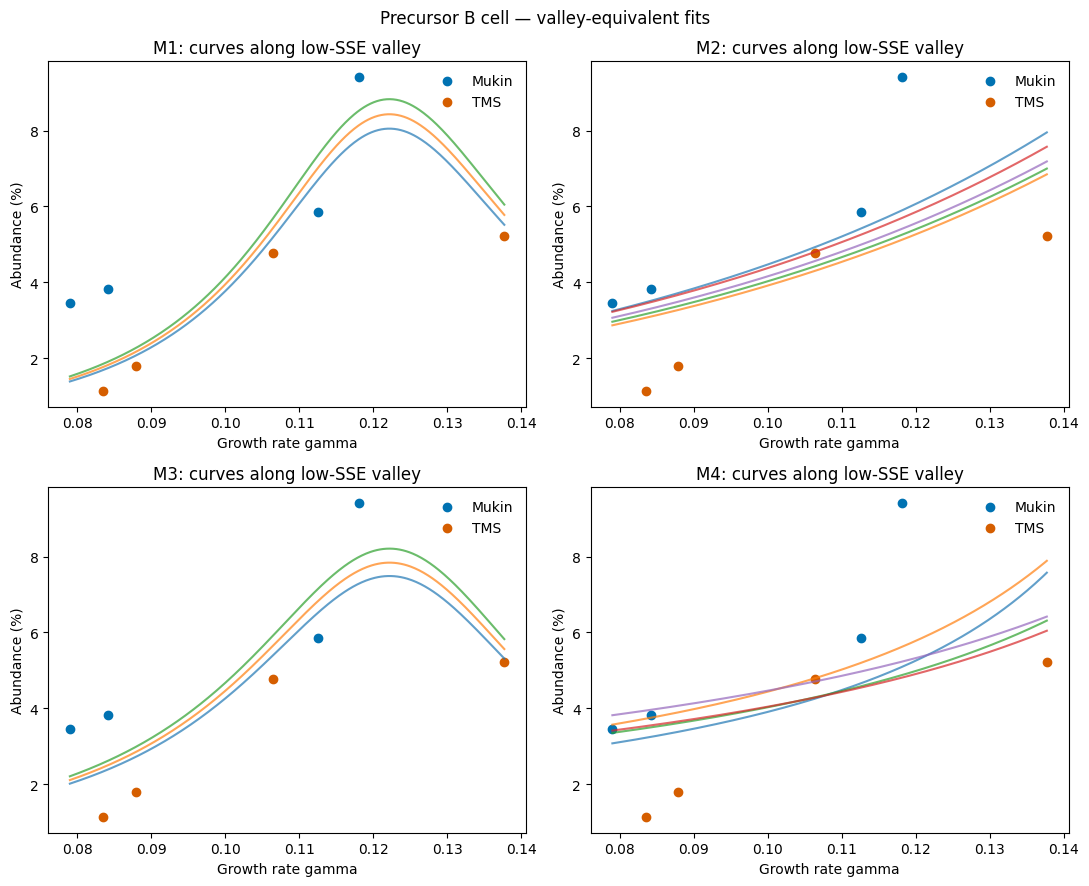

Searching Dendritic: eight combined conditions


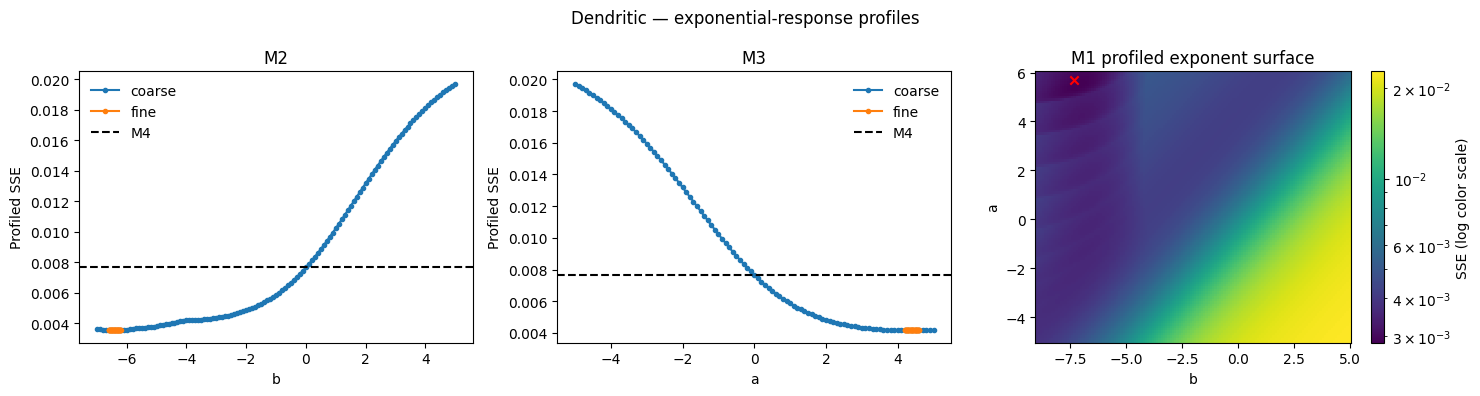

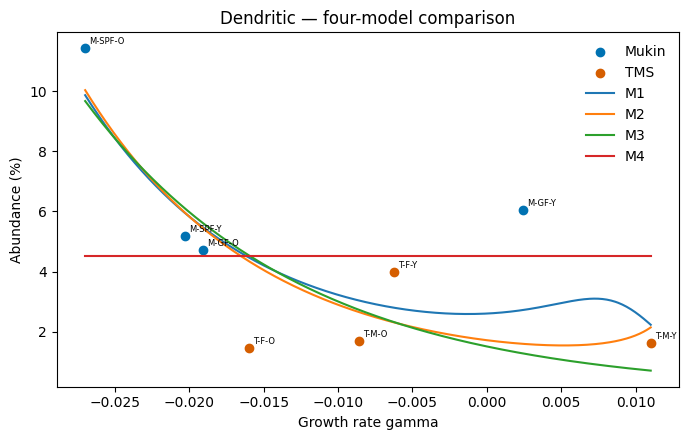

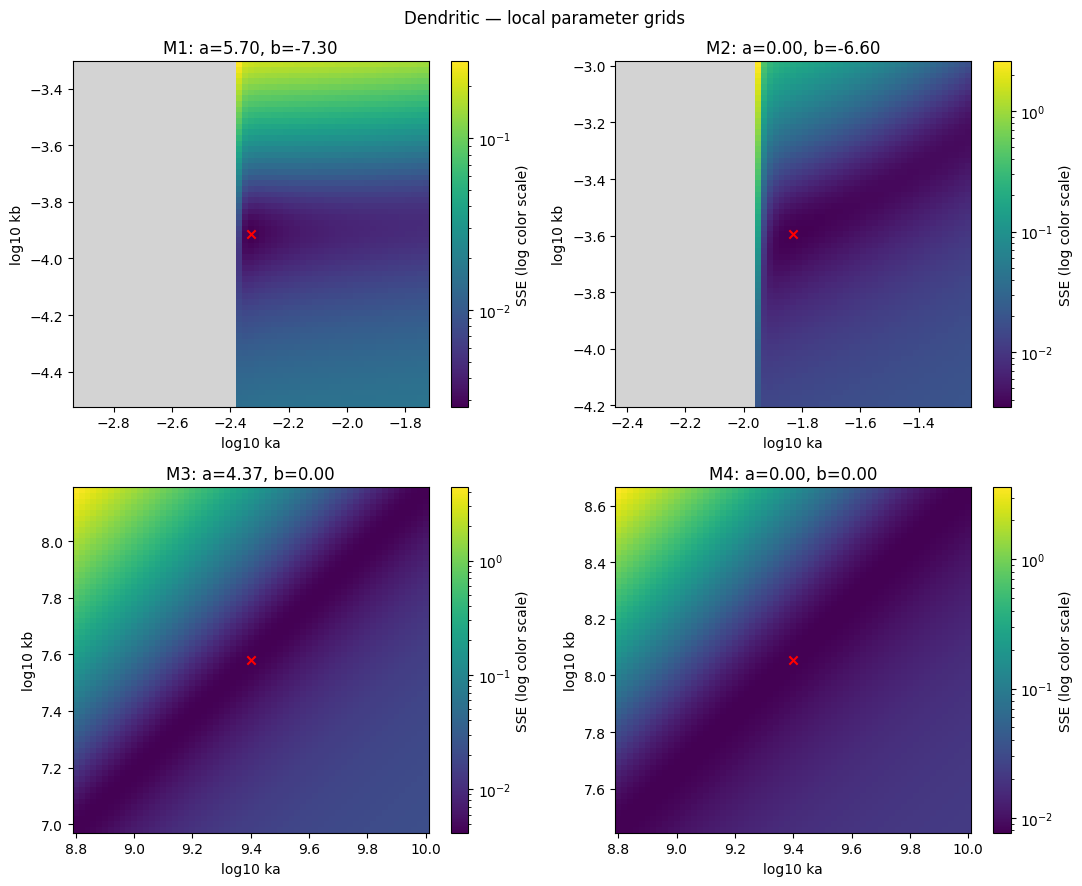

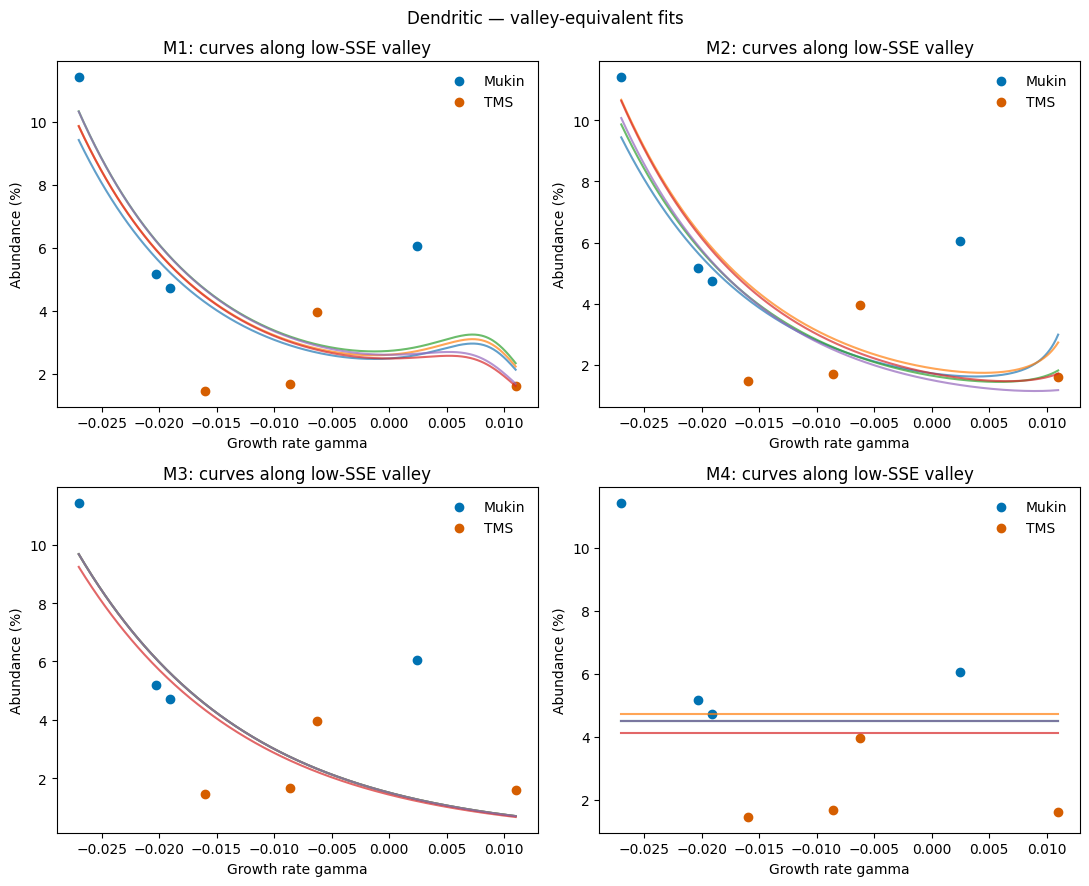

Searching Promonocyte: eight combined conditions


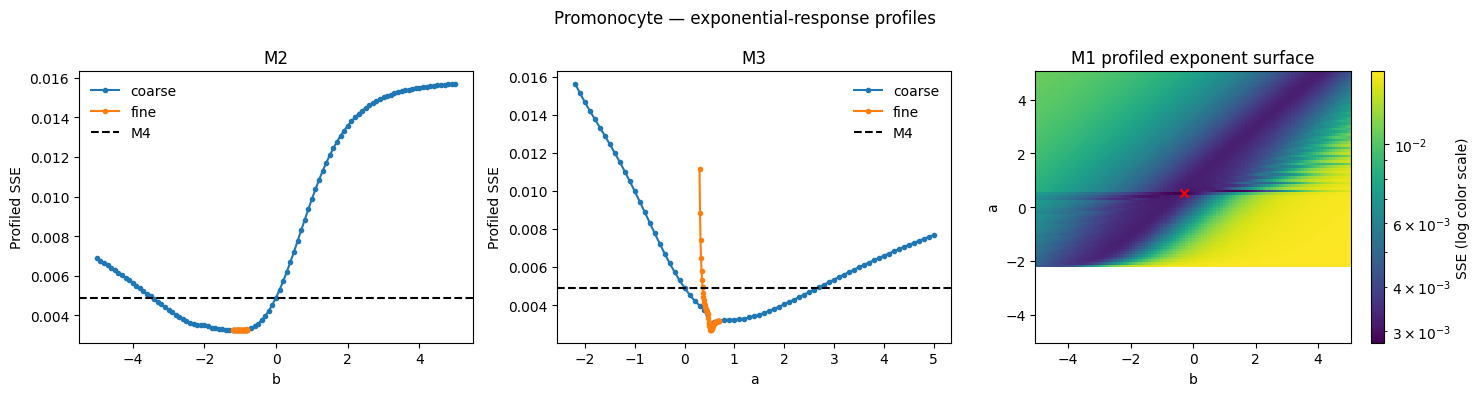

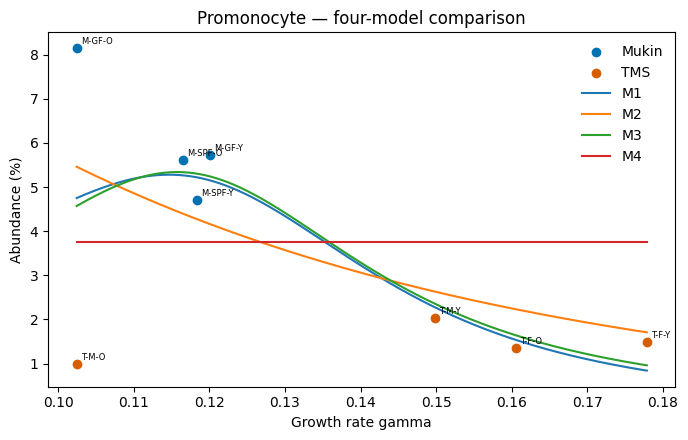

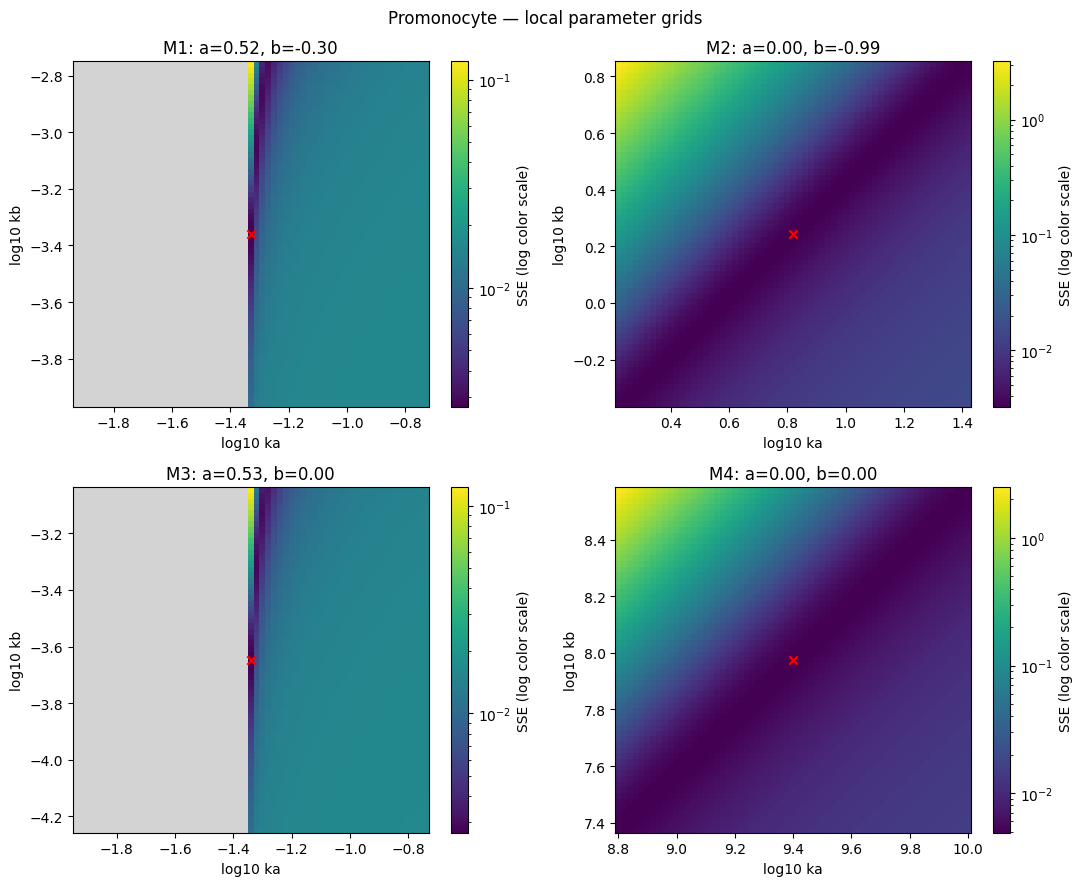

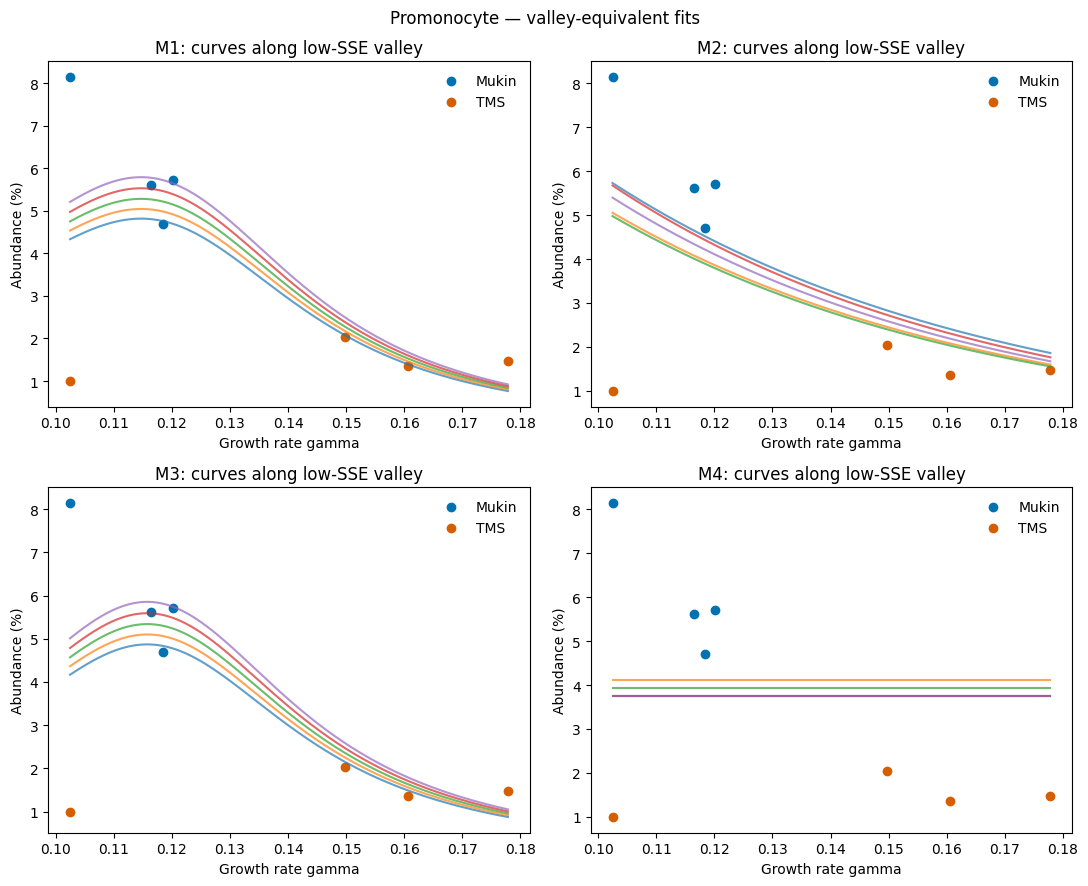

Searching Myeloid progenitor: eight combined conditions


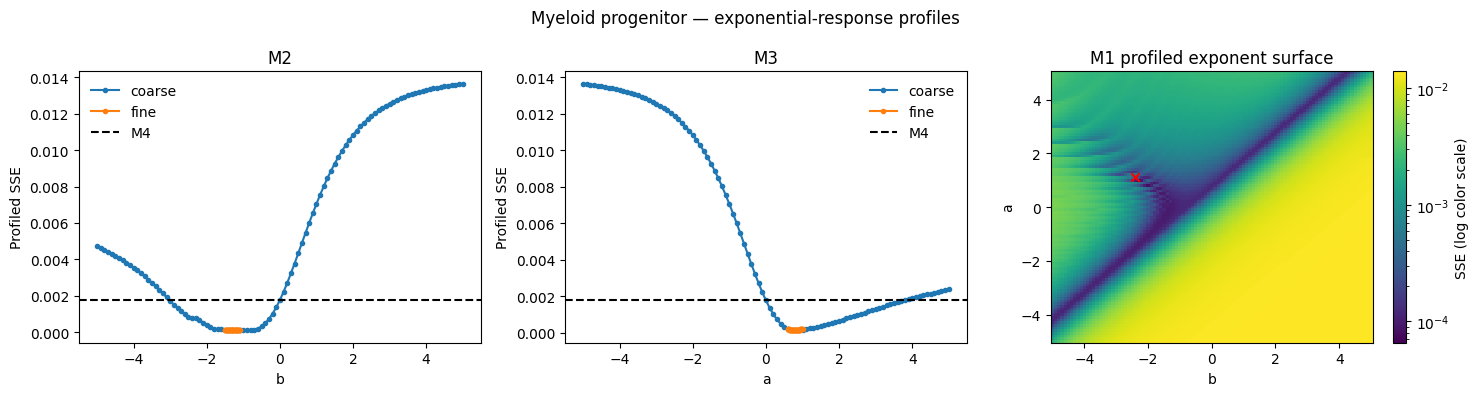

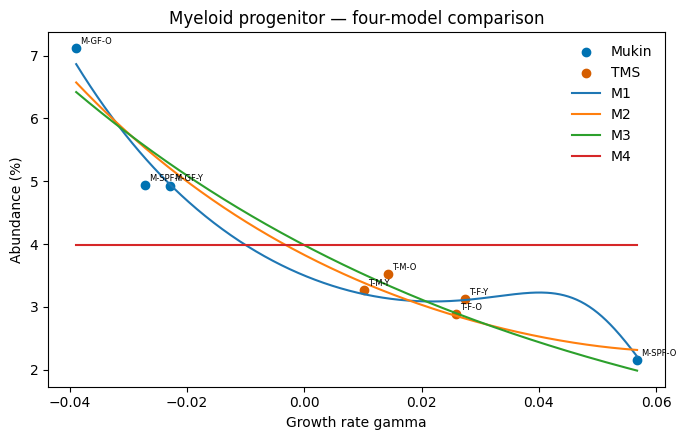

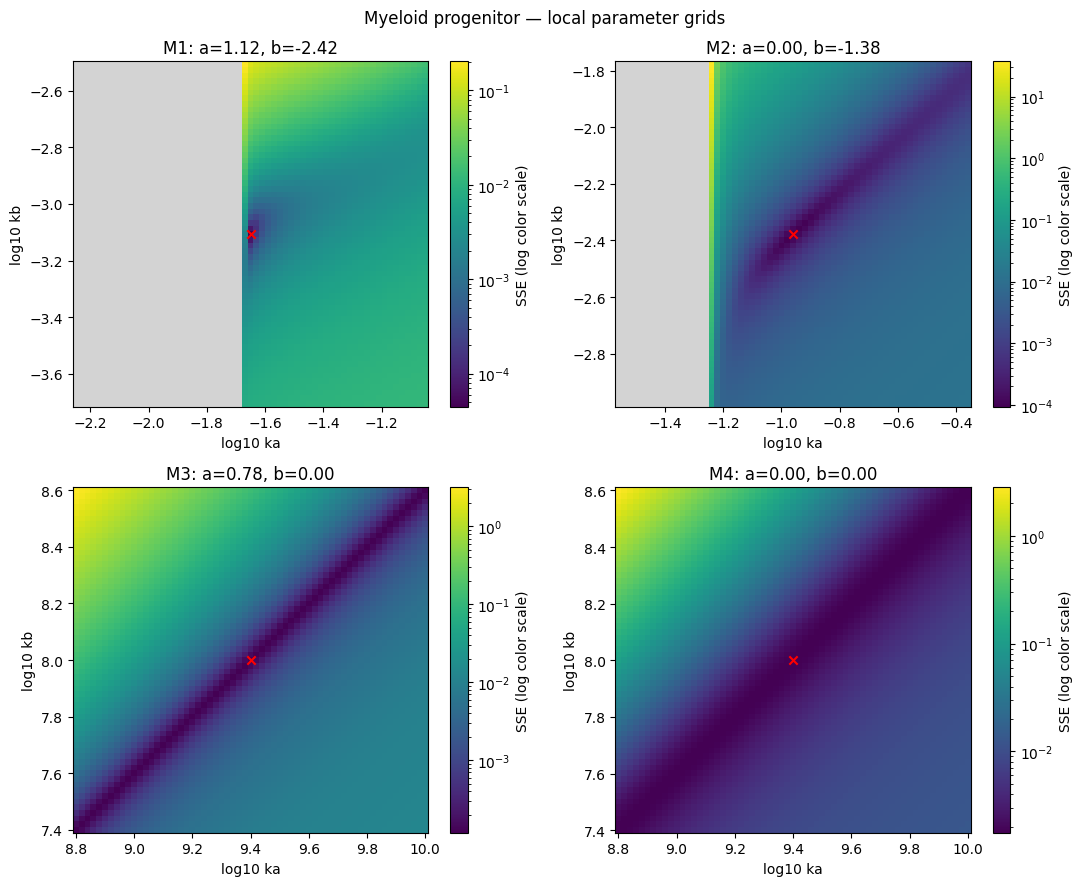

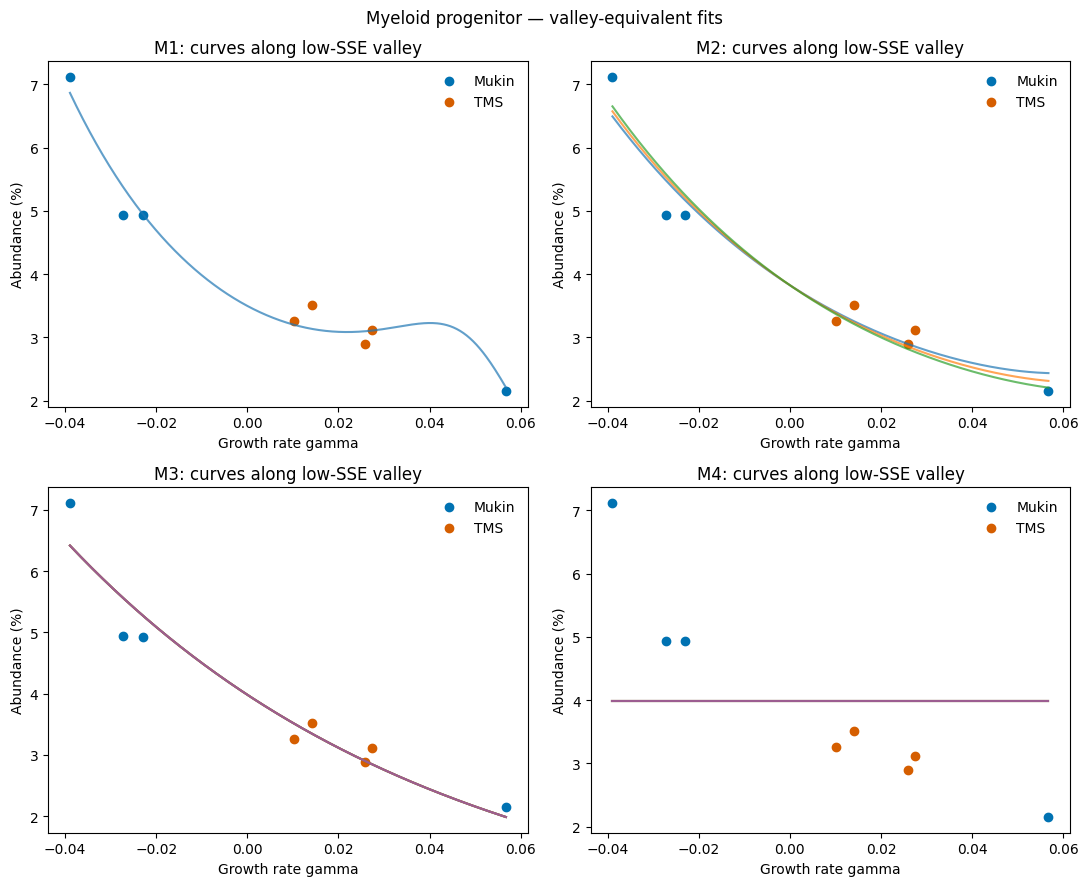

Searching Myelomonocyte: eight combined conditions


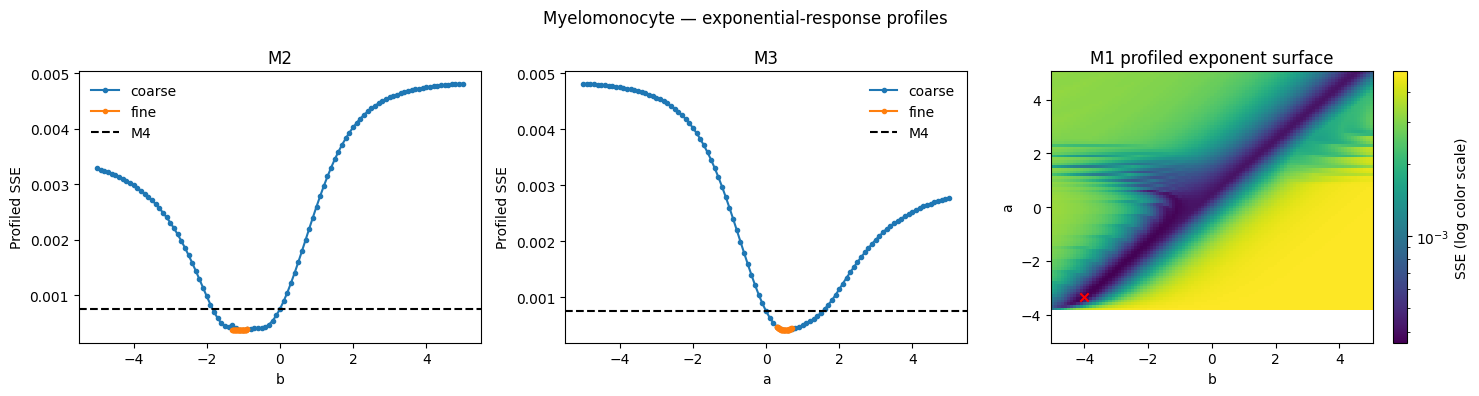

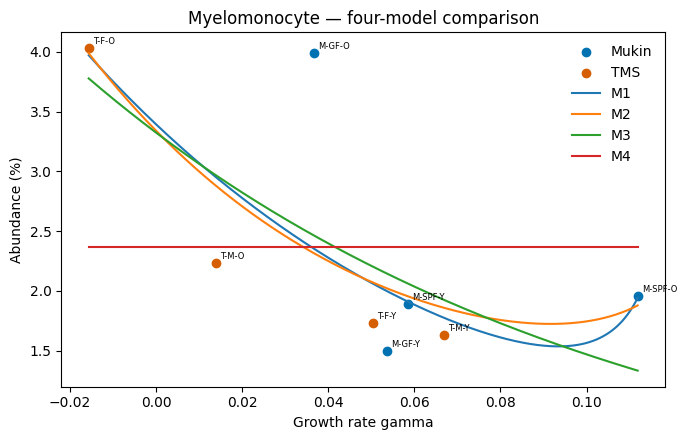

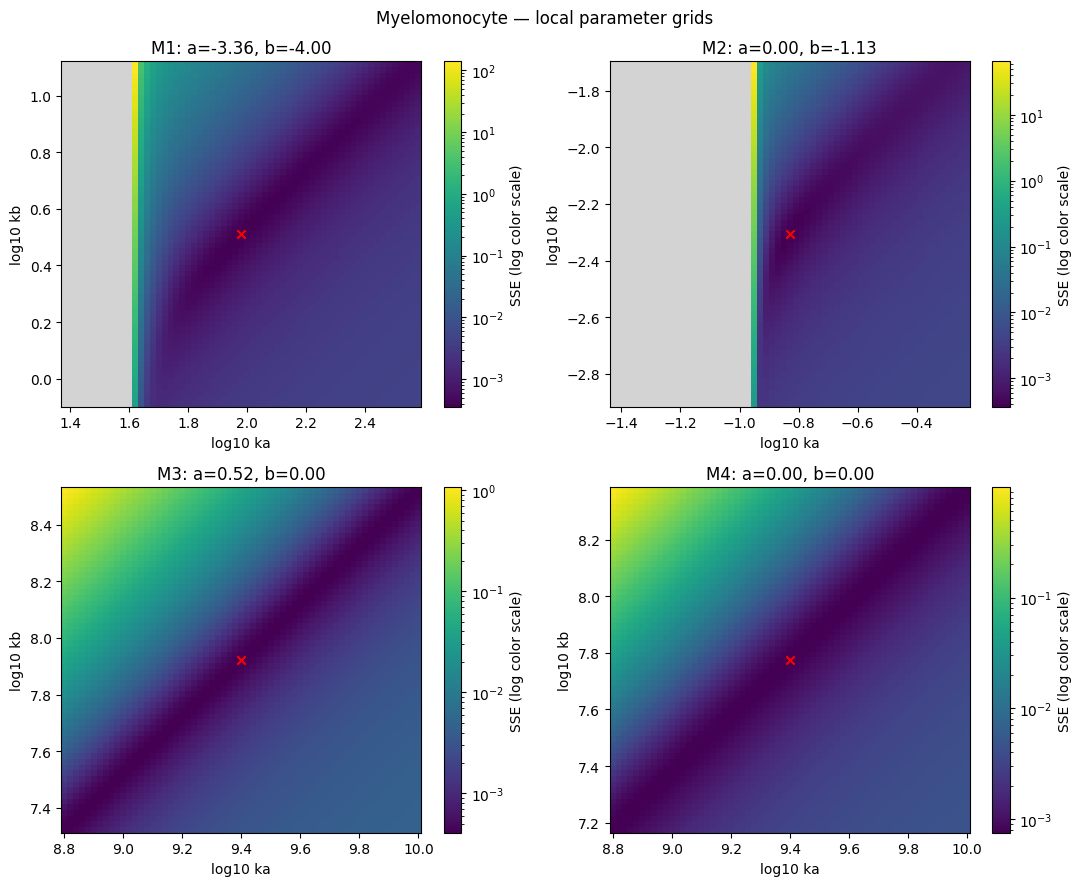

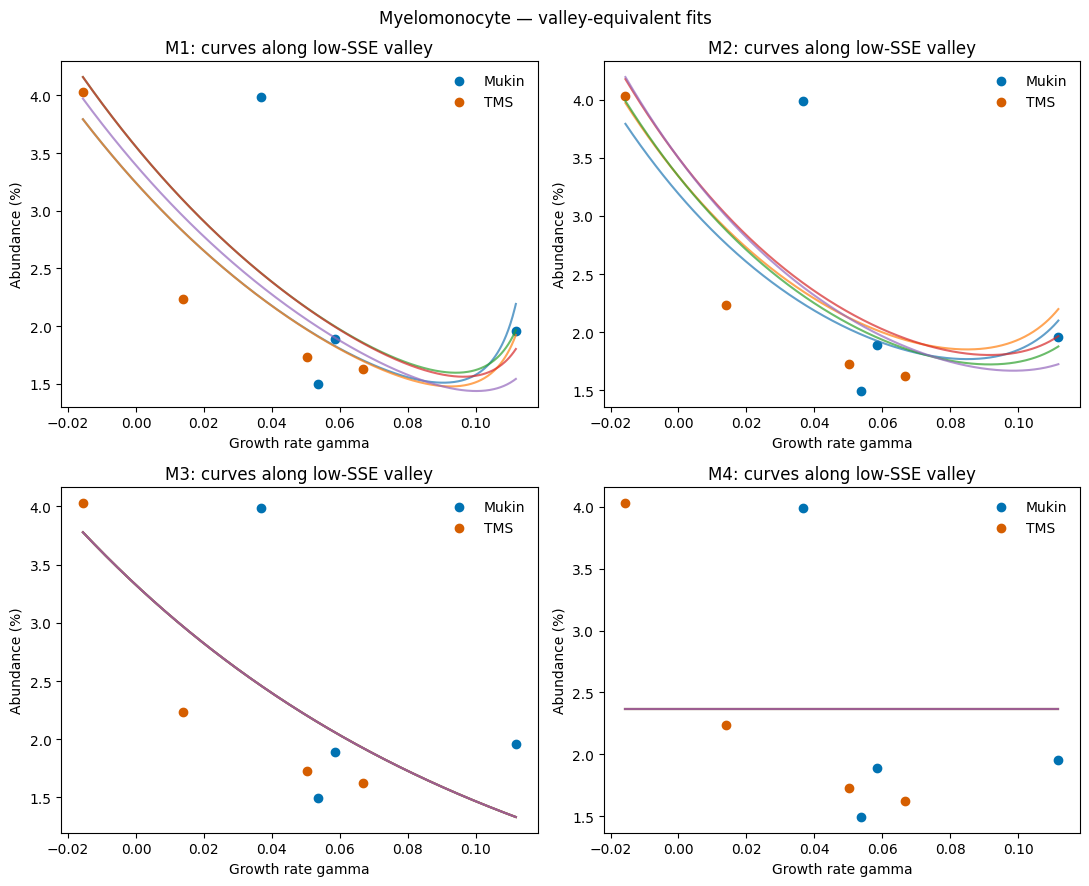

Searching T CD8: eight combined conditions


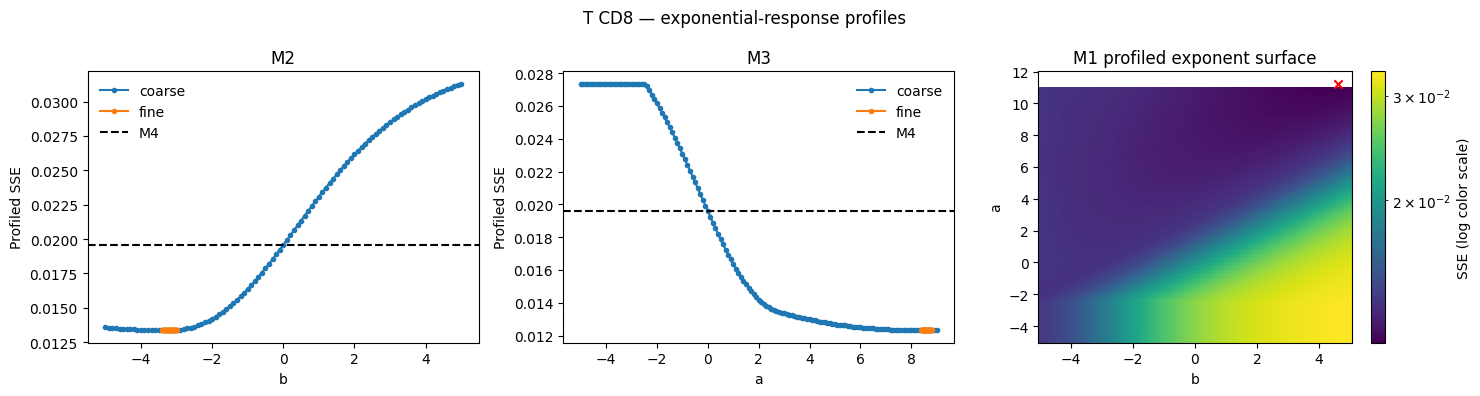

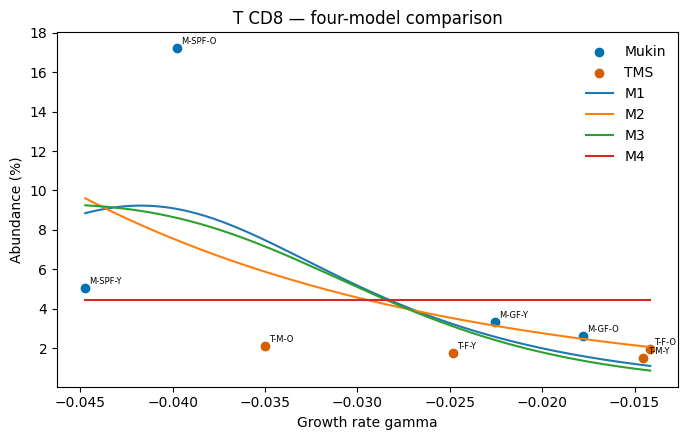

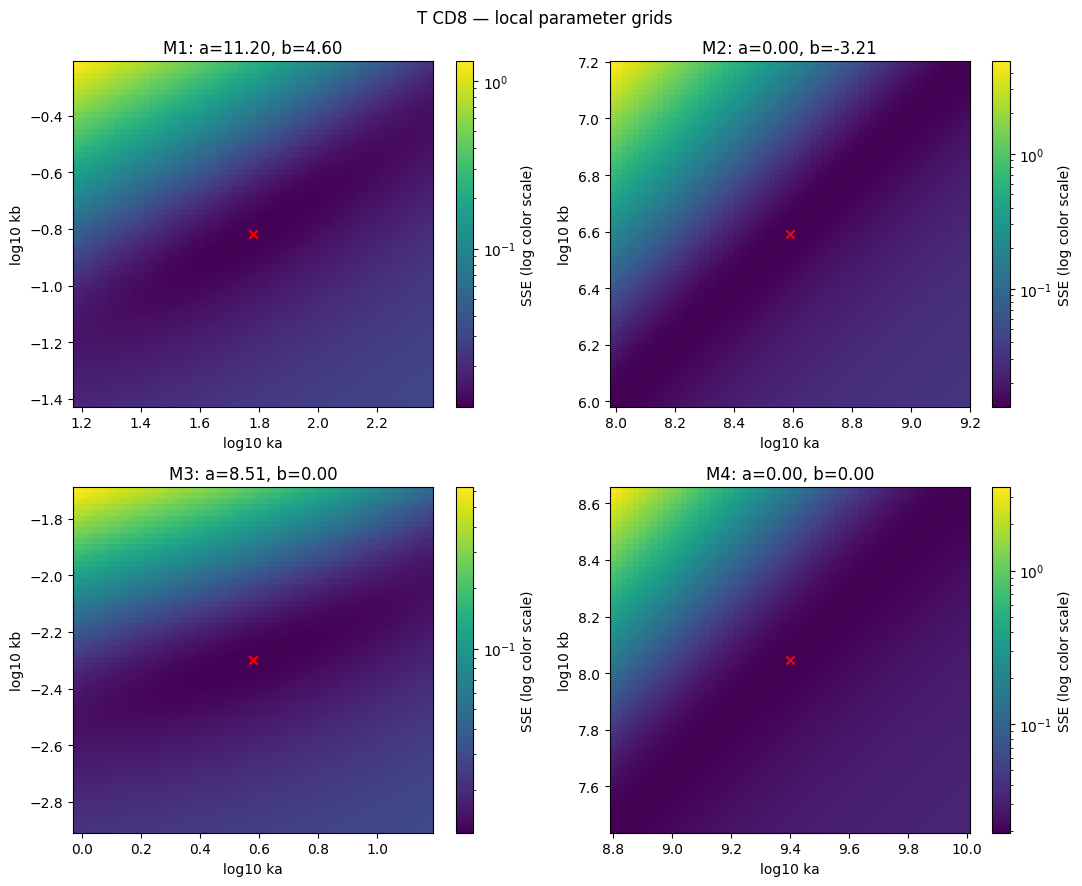

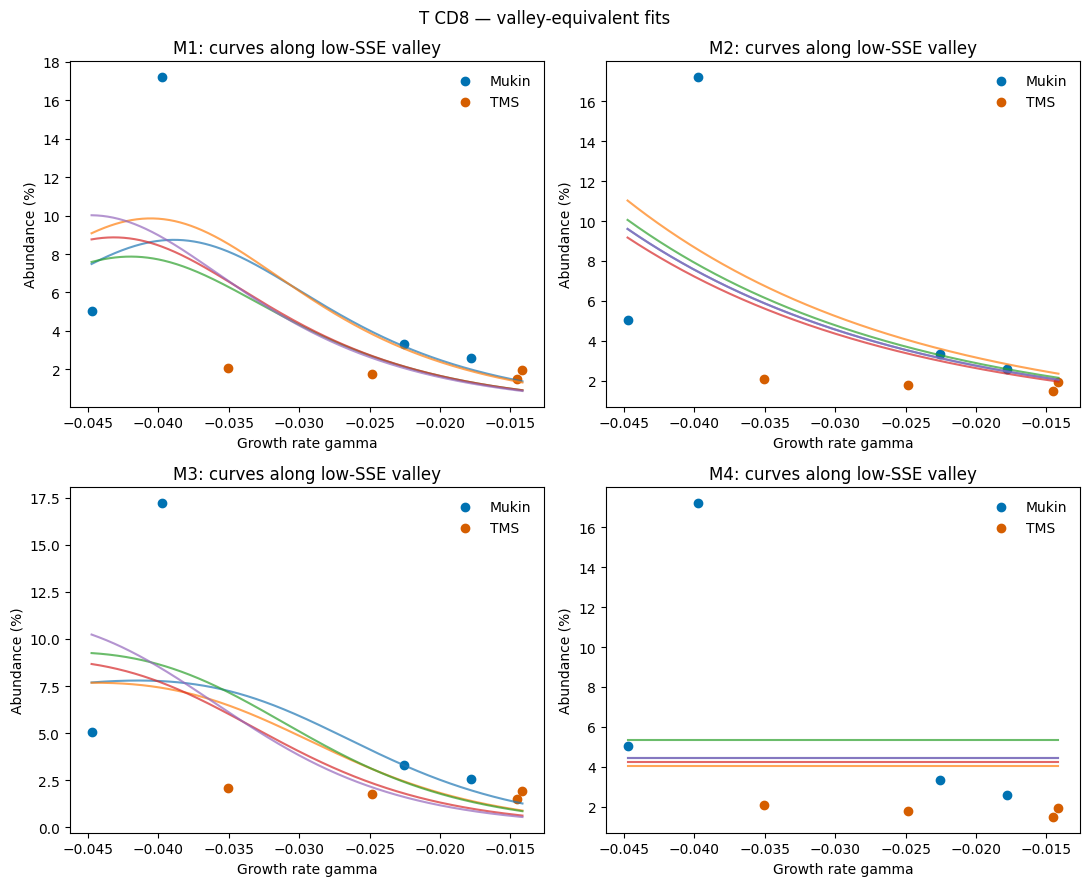

          celltype model    constraint  n_conditions  n_parameters  n_positive_gamma  n_zero_gamma  n_negative_gamma  gamma_ref  s_gamma_global     a     b           ka           kb      SSE  RMSE_percent        AIC       AICc        BIC  min_denominator          status                                                                                                                                                                                 source_csv  delta_AICc  AICc_best
         Dendritic    M2 a = 0, b free             8             3                 2             0                 6        0.0        0.063578  0.00 -6.60 1.479108e-02 2.544716e-04 0.003521      2.097898 -55.827745 -49.827745 -55.589421     3.779514e-03 edge_unresolved mukin_old_spf_vs_old_gf_tidyi.csv;mukin_young_spf_vs_old_spf_tidyi.csv;mukin_young_spf_vs_young_gf_tidyi.csv;tms_old_male_vs_old_female_tidyi.csv;tms_young_male_vs_young_female_tidyi.csv    0.000000       True
         Dendritic    M4     a = b = 0

In [5]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.colors import LogNorm

# This refined module is independent of earlier notebook variables.
rates_dir = Path("/scratch/chenxi.sun/TIDYI_Astrid-anno/ty_df")
output_dir = Path("/scratch/chenxi.sun/RA project/system_biology/outputs")
output_dir.mkdir(exist_ok=True)
rate_inputs = [
    ("mukin_young_spf_vs_old_spf_tidyi.csv", "Mukin", "Bone-marrow", ["young_spf", "old_spf"]),
    ("mukin_young_spf_vs_young_gf_tidyi.csv", "Mukin", "Bone-marrow", ["young_gf"]),
    ("mukin_old_spf_vs_old_gf_tidyi.csv", "Mukin", "Bone-marrow", ["old_gf"]),
    ("tms_young_male_vs_young_female_tidyi.csv", "TMS", "Marrow", ["young_male", "young_female"]),
    ("tms_old_male_vs_old_female_tidyi.csv", "TMS", "Marrow", ["old_male", "old_female"]),
]
condition_codes = {
    "young_spf": "M-SPF-Y", "old_spf": "M-SPF-O",
    "young_gf": "M-GF-Y", "old_gf": "M-GF-O",
    "young_male": "T-M-Y", "young_female": "T-F-Y",
    "old_male": "T-M-O", "old_female": "T-F-O",
}
selected_celltypes = {
    "b pre": "Precursor B cell",
    "dendritic": "Dendritic",
    "monocyte pro": "Promonocyte",
    "myeloid progenitor": "Myeloid progenitor",
    "myelomonocyte": "Myelomonocyte",
    "t cd8": "T CD8",
}
dataset_colors = {"Mukin": "#0072B2", "TMS": "#D55E00"}
model_order = ["M1", "M2", "M3", "M4"]
model_constraints = {
    "M1": "a and b free",
    "M2": "a = 0, b free",
    "M3": "a free, b = 0",
    "M4": "a = b = 0",
}
parameter_counts = {"M1": 4, "M2": 3, "M3": 3, "M4": 2}

rate_tables = []
for filename, dataset, tissue, groups in rate_inputs:
    table = pd.read_csv(rates_dir / filename)
    table = table[(table["tissue"] == tissue) & table["comparison_group"].isin(groups)].copy()
    table["dataset"] = dataset
    table["source_csv"] = filename
    rate_tables.append(table)

m23r_data = pd.concat(rate_tables, ignore_index=True)
m23r_data["celltype"] = m23r_data["celltype"].astype("string").str.strip().str.lower()
m23r_data["condition_code"] = m23r_data["comparison_group"].map(condition_codes)
m23r_data["gamma"] = m23r_data["prolif_rate"] - m23r_data["death_rate"]
m23r_data["abundance_fraction"] = m23r_data["percentage"] / 100
assert not m23r_data.duplicated(["dataset", "comparison_group", "celltype"]).any()
coverage = m23r_data.groupby("celltype")["comparison_group"].nunique()
assert set(selected_celltypes).issubset(set(coverage[coverage == 8].index))
m23r_data = m23r_data[m23r_data["celltype"].isin(selected_celltypes)].copy()
assert len(m23r_data) == 6 * 8
assert m23r_data.groupby("celltype").size().eq(8).all()
assert m23r_data.groupby(["celltype", "dataset"]).size().eq(4).all()
assert np.isfinite(m23r_data[["gamma", "abundance_fraction"]]).all().all()
assert m23r_data["abundance_fraction"].between(0, 1).all()

# One global scale from every included cell-type/condition gamma (sample SD, ddof=1).
gamma_ref = 0.0
s_gamma = m23r_data["gamma"].std(ddof=1)
assert np.isfinite(s_gamma) and s_gamma > 0
m23r_data["z"] = (m23r_data["gamma"] - gamma_ref) / s_gamma
print(f"Global s_gamma = {s_gamma:.8g} from {len(m23r_data)} gamma values")
print("Gamma sign counts:", m23r_data["gamma"].gt(0).sum(), "positive,",
      m23r_data["gamma"].eq(0).sum(), "zero,",
      m23r_data["gamma"].lt(0).sum(), "negative")

exponent_bounds = (-5.0, 5.0)
exponent_step = 0.1
fine_exponent_step = 0.01
max_extensions = 6


def exponent_values(lo, hi, step):
    return np.round(np.arange(lo, hi + step / 2, step), 10)


def fit_exponent_surface(gamma, z, x, a_values, b_values,
                         logka_bounds=(-6.0, 2.0), logka_step=0.1,
                         extension_width=1.0):
    """Profile ka and kb for every (a, b); kb has a positive least-squares solution."""
    bounds = list(logka_bounds)
    a_values = np.asarray(a_values, dtype=float)
    b_values = np.asarray(b_values, dtype=float)

    for extension in range(max_extensions + 1):
        logka = exponent_values(bounds[0], bounds[1], logka_step)
        ka_values = 10.0 ** logka
        surface_sse = np.full((len(a_values), len(b_values)), np.inf)
        surface_ka = np.full_like(surface_sse, np.nan)
        surface_kb = np.full_like(surface_sse, np.nan)
        surface_logka_index = np.full(surface_sse.shape, -1, dtype=int)

        with np.errstate(over="ignore", divide="ignore", invalid="ignore"):
            exp_bz = np.exp(np.outer(b_values, z))
            for ia, a in enumerate(a_values):
                denominator = ka_values[:, None] * np.exp(a * z)[None, :] - gamma[None, :]
                valid_ka = np.isfinite(denominator).all(axis=1) & (denominator > 0).all(axis=1)
                valid_indices = np.flatnonzero(valid_ka)
                if not len(valid_indices):
                    continue
                q = exp_bz[:, None, :] / denominator[valid_ka][None, :, :]
                qtx = np.sum(q * x[None, None, :], axis=2)
                qtq = np.sum(q * q, axis=2)
                kb = qtx / qtq
                sse = np.sum((kb[:, :, None] * q - x[None, None, :]) ** 2, axis=2)
                sse[(kb <= 0) | ~np.isfinite(sse)] = np.inf
                local_index = np.argmin(sse, axis=1)
                rows = np.arange(len(b_values))
                chosen_index = valid_indices[local_index]
                surface_sse[ia] = sse[rows, local_index]
                surface_ka[ia] = ka_values[chosen_index]
                surface_kb[ia] = kb[rows, local_index]
                surface_logka_index[ia] = chosen_index

        if not np.isfinite(surface_sse).any():
            if extension == max_extensions:
                raise ValueError("No feasible point: increase the log10(ka) upper bound.")
            bounds[1] += extension_width
            continue

        ia, ib = np.unravel_index(np.argmin(surface_sse), surface_sse.shape)
        ika = surface_logka_index[ia, ib]
        lower_edge = ika == 0
        upper_edge = ika == len(logka) - 1
        if not (lower_edge or upper_edge) or extension == max_extensions:
            break
        bounds[0] -= extension_width * lower_edge
        bounds[1] += extension_width * upper_edge

    return {
        "a_values": a_values, "b_values": b_values,
        "surface_sse": surface_sse, "surface_ka": surface_ka, "surface_kb": surface_kb,
        "a": a_values[ia], "b": b_values[ib], "ka": surface_ka[ia, ib],
        "kb": surface_kb[ia, ib], "SSE": surface_sse[ia, ib],
        "ia": ia, "ib": ib, "logka": logka,
        "parameter_edge": bool(lower_edge or upper_edge),
    }


def model_axes(model, a_bounds, b_bounds, step):
    if model == "M1":
        return exponent_values(*a_bounds, step), exponent_values(*b_bounds, step)
    if model == "M2":
        return np.array([0.0]), exponent_values(*b_bounds, step)
    if model == "M3":
        return exponent_values(*a_bounds, step), np.array([0.0])
    return np.array([0.0]), np.array([0.0])


def fit_model(gamma, z, x, model):
    a_bounds = list(exponent_bounds)
    b_bounds = list(exponent_bounds)
    for extension in range(max_extensions + 1):
        a_values, b_values = model_axes(model, a_bounds, b_bounds, exponent_step)
        coarse = fit_exponent_surface(gamma, z, x, a_values, b_values)
        a_edge = model in ("M1", "M3") and coarse["ia"] in (0, len(a_values) - 1)
        b_edge = model in ("M1", "M2") and coarse["ib"] in (0, len(b_values) - 1)
        if not (a_edge or b_edge) or extension == max_extensions:
            break
        if a_edge:
            a_bounds[0] -= float(coarse["ia"] == 0)
            a_bounds[1] += float(coarse["ia"] == len(a_values) - 1)
        if b_edge:
            b_bounds[0] -= float(coarse["ib"] == 0)
            b_bounds[1] += float(coarse["ib"] == len(b_values) - 1)

    fine_a_bounds = (coarse["a"] - 0.2, coarse["a"] + 0.2)
    fine_b_bounds = (coarse["b"] - 0.2, coarse["b"] + 0.2)
    fine_a, fine_b = model_axes(model, fine_a_bounds, fine_b_bounds, fine_exponent_step)
    fine = fit_exponent_surface(
        gamma, z, x, fine_a, fine_b,
        logka_bounds=(np.log10(coarse["ka"]) - 0.2, np.log10(coarse["ka"]) + 0.2),
        logka_step=0.01, extension_width=0.2,
    )
    fine["exponent_edge"] = bool(
        a_edge or b_edge or
        (model in ("M1", "M3") and fine["ia"] in (0, len(fine_a) - 1)) or
        (model in ("M1", "M2") and fine["ib"] in (0, len(fine_b) - 1))
    )
    return fine, coarse


def parameter_diagnostic_grid(gamma, z, x, fit, half_width=0.6, step=0.02):
    logka = exponent_values(np.log10(fit["ka"]) - half_width,
                            np.log10(fit["ka"]) + half_width, step)
    logkb = exponent_values(np.log10(fit["kb"]) - half_width,
                            np.log10(fit["kb"]) + half_width, step)
    ka = 10.0 ** logka
    kb = 10.0 ** logkb
    with np.errstate(over="ignore", divide="ignore", invalid="ignore"):
        denominator = ka[:, None] * np.exp(fit["a"] * z)[None, :] - gamma[None, :]
        valid = np.isfinite(denominator).all(axis=1) & (denominator > 0).all(axis=1)
        sse = np.full((len(kb), len(ka)), np.inf)
        q = np.exp(fit["b"] * z)[None, :] / denominator[valid]
        prediction = kb[:, None, None] * q[None, :, :]
        sse[:, valid] = np.sum((prediction - x[None, None, :]) ** 2, axis=2)
    return {"logka": logka, "logkb": logkb, "sse": sse}


def select_valley_points(grid, tolerance=0.05, n_points=5):
    finite = np.isfinite(grid["sse"])
    if not finite.any():
        return pd.DataFrame()
    threshold = grid["sse"][finite].min() * (1 + tolerance)
    iy, ix = np.where(finite & (grid["sse"] <= threshold))
    valley = pd.DataFrame({
        "log10_ka": grid["logka"][ix],
        "log10_kb": grid["logkb"][iy],
        "SSE": grid["sse"][iy, ix],
    }).sort_values(["log10_ka", "log10_kb"])
    if len(valley) > n_points:
        valley = valley.iloc[np.linspace(0, len(valley) - 1, n_points).astype(int)]
    valley = valley.copy()
    valley["ka"] = 10.0 ** valley["log10_ka"]
    valley["kb"] = 10.0 ** valley["log10_kb"]
    return valley


def predict(gamma, z, a, b, ka, kb):
    with np.errstate(over="ignore", divide="ignore", invalid="ignore"):
        denominator = ka * np.exp(a * z) - gamma
        prediction = kb * np.exp(b * z) / denominator
    prediction[~np.isfinite(prediction) | (denominator <= 0)] = np.nan
    return prediction, denominator


result_rows = []
profile_tables = []
all_fits = {}
for celltype, label in selected_celltypes.items():
    data = m23r_data[m23r_data["celltype"] == celltype].sort_values(["dataset", "condition_code"])
    gamma = data["gamma"].to_numpy(dtype=float)
    z = data["z"].to_numpy(dtype=float)
    x = data["abundance_fraction"].to_numpy(dtype=float)
    print(f"Searching {label}: eight combined conditions", flush=True)

    fitted = {}
    coarse_profiles = {}
    diagnostic_grids = {}
    for model in model_order:
        fitted[model], coarse_profiles[model] = fit_model(gamma, z, x, model)
        diagnostic_grids[model] = parameter_diagnostic_grid(gamma, z, x, fitted[model])
        for stage, profile in [("coarse", coarse_profiles[model]), ("fine", fitted[model])]:
            aa, bb = np.meshgrid(profile["a_values"], profile["b_values"], indexing="ij")
            profile_tables.append(pd.DataFrame({
                "celltype": label, "model": model, "stage": stage,
                "a": aa.ravel(), "b": bb.ravel(),
                "ka": profile["surface_ka"].ravel(),
                "kb": profile["surface_kb"].ravel(),
                "SSE": profile["surface_sse"].ravel(),
            }))
    all_fits[label] = fitted

    n = len(x)
    cell_rows = []
    for model in model_order:
        fit = fitted[model]
        observed_prediction, observed_denominator = predict(
            gamma, z, fit["a"], fit["b"], fit["ka"], fit["kb"]
        )
        assert np.isfinite(observed_prediction).all()
        assert (observed_denominator > 0).all()
        assert fit["ka"] > 0 and fit["kb"] > 0
        k = parameter_counts[model]
        sse_for_ic = max(fit["SSE"], np.finfo(float).tiny)
        aic = n * np.log(sse_for_ic / n) + 2 * k
        aicc = aic + 2 * k * (k + 1) / (n - k - 1)
        bic = n * np.log(sse_for_ic / n) + k * np.log(n)
        cell_rows.append({
            "celltype": label, "model": model, "constraint": model_constraints[model],
            "n_conditions": n, "n_parameters": k,
            "n_positive_gamma": int((gamma > 0).sum()),
            "n_zero_gamma": int((gamma == 0).sum()),
            "n_negative_gamma": int((gamma < 0).sum()),
            "gamma_ref": gamma_ref, "s_gamma_global": s_gamma,
            "a": fit["a"], "b": fit["b"], "ka": fit["ka"], "kb": fit["kb"],
            "SSE": fit["SSE"], "RMSE_percent": 100 * np.sqrt(fit["SSE"] / n),
            "AIC": aic, "AICc": aicc, "BIC": bic,
            "min_denominator": observed_denominator.min(),
            "status": "edge_unresolved" if fit["parameter_edge"] or fit["exponent_edge"] else "grid_interior",
            "source_csv": ";".join(sorted(data["source_csv"].unique())),
        })
    cell_rows = pd.DataFrame(cell_rows)
    cell_rows["delta_AICc"] = cell_rows["AICc"] - cell_rows["AICc"].min()
    cell_rows["AICc_best"] = cell_rows["delta_AICc"].eq(0)
    result_rows.extend(cell_rows.to_dict("records"))

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    for ax, model, exponent_name in [(axes[0], "M2", "b"), (axes[1], "M3", "a")]:
        profile = coarse_profiles[model]
        exponent = profile["b_values"] if model == "M2" else profile["a_values"]
        ax.plot(exponent, profile["surface_sse"].ravel(), ".-", label="coarse")
        fine = fitted[model]
        fine_exponent = fine["b_values"] if model == "M2" else fine["a_values"]
        ax.plot(fine_exponent, fine["surface_sse"].ravel(), ".-", label="fine")
        ax.axhline(fitted["M4"]["SSE"], color="black", linestyle="--", label="M4")
        ax.set(xlabel=exponent_name, ylabel="Profiled SSE", title=model)
        ax.legend(frameon=False)
    m1_profile = coarse_profiles["M1"]
    finite = m1_profile["surface_sse"][np.isfinite(m1_profile["surface_sse"])]
    mesh = axes[2].pcolormesh(
        m1_profile["b_values"], m1_profile["a_values"],
        np.ma.masked_invalid(m1_profile["surface_sse"]), shading="auto", cmap="viridis",
        norm=LogNorm(vmin=max(finite.min(), 1e-16), vmax=max(finite.max(), 1e-15)),
    )
    axes[2].scatter(fitted["M1"]["b"], fitted["M1"]["a"], color="red", marker="x")
    axes[2].set(xlabel="b", ylabel="a", title="M1 profiled exponent surface")
    fig.colorbar(mesh, ax=axes[2], label="SSE (log color scale)")
    fig.suptitle(label + " — exponential-response profiles")
    fig.tight_layout()
    fig.savefig(output_dir / f"M23_refined_profiles_{celltype.replace(' ', '_')}.png", dpi=300, bbox_inches="tight")
    plt.show()
    plt.close(fig)

    fig, ax = plt.subplots(figsize=(7, 4.5))
    for dataset, points in data.groupby("dataset"):
        ax.scatter(points["gamma"], points["percentage"], color=dataset_colors[dataset], label=dataset)
    for row in data.itertuples():
        ax.annotate(row.condition_code, (row.gamma, row.percentage),
                    xytext=(3, 3), textcoords="offset points", fontsize=6)
    curve_gamma = np.linspace(gamma.min(), gamma.max(), 400)
    curve_z = (curve_gamma - gamma_ref) / s_gamma
    for model in model_order:
        fit = fitted[model]
        curve, _ = predict(curve_gamma, curve_z, fit["a"], fit["b"], fit["ka"], fit["kb"])
        ax.plot(curve_gamma, 100 * curve, label=model)
    ax.set(xlabel="Growth rate gamma", ylabel="Abundance (%)", title=label + " — four-model comparison")
    ax.legend(frameon=False)
    fig.tight_layout()
    fig.savefig(output_dir / f"M23_refined_fits_{celltype.replace(' ', '_')}.png", dpi=300, bbox_inches="tight")
    plt.show()
    plt.close(fig)

    fig, axes = plt.subplots(2, 2, figsize=(11, 9))
    for ax, model in zip(axes.ravel(), model_order):
        grid = diagnostic_grids[model]
        finite = grid["sse"][np.isfinite(grid["sse"])]
        mesh = ax.pcolormesh(
            grid["logka"], grid["logkb"], np.ma.masked_invalid(grid["sse"]),
            shading="auto", cmap="viridis",
            norm=LogNorm(vmin=max(finite.min(), 1e-16), vmax=max(finite.max(), 1e-15)),
        )
        ax.set_facecolor("lightgray")
        ax.scatter(np.log10(fitted[model]["ka"]), np.log10(fitted[model]["kb"]),
                   color="red", marker="x")
        ax.set(xlabel="log10 ka", ylabel="log10 kb",
               title=f'{model}: a={fitted[model]["a"]:.2f}, b={fitted[model]["b"]:.2f}')
        fig.colorbar(mesh, ax=ax, label="SSE (log color scale)")
    fig.suptitle(label + " — local parameter grids")
    fig.tight_layout()
    fig.savefig(output_dir / f"M23_refined_parameter_grids_{celltype.replace(' ', '_')}.png", dpi=300, bbox_inches="tight")
    plt.show()
    plt.close(fig)

    fig, axes = plt.subplots(2, 2, figsize=(11, 9))
    for ax, model in zip(axes.ravel(), model_order):
        fit = fitted[model]
        valley = select_valley_points(diagnostic_grids[model], tolerance=0.05, n_points=5)
        for row in valley.itertuples():
            curve, _ = predict(curve_gamma, curve_z, fit["a"], fit["b"], row.ka, row.kb)
            ax.plot(curve_gamma, 100 * curve, alpha=0.7)
        for dataset, points in data.groupby("dataset"):
            ax.scatter(points["gamma"], points["percentage"],
                       color=dataset_colors[dataset], label=dataset)
        ax.set(xlabel="Growth rate gamma", ylabel="Abundance (%)",
               title=f"{model}: curves along low-SSE valley")
        ax.legend(frameon=False)
    fig.suptitle(label + " — valley-equivalent fits")
    fig.tight_layout()
    fig.savefig(output_dir / f"M23_refined_valleys_{celltype.replace(' ', '_')}.png", dpi=300, bbox_inches="tight")
    plt.show()
    plt.close(fig)

m23r_results = pd.DataFrame(result_rows)
m23r_profiles = pd.concat(profile_tables, ignore_index=True)
m23r_results.to_csv(output_dir / "M23_refined_exponential_results.csv", index=False)
m23r_profiles.to_csv(output_dir / "M23_refined_exponential_profiles.csv", index=False)
print(m23r_results.sort_values(["celltype", "AICc"]).to_string(index=False))